**Predicting 30-Day Hospital Readmission in Dialysis Patients
Using Temporal Fusion Transformer (TFT)**

> Dataset: Hemodialysis Real-Time Hospital Dataset (Kaggle — gskrdsolutions)  
> Model: Temporal Fusion Transformer (pytorch-forecasting)

>Novelty : SHAP Interaction values reveals joint effects of dialysis metrics and comorbidities
> Goal: Predict 30-day unplanned hospital readmission for dialysis patients  

### Pipeline Overview
```
1. Environment Setup & Imports
2. Data Loading & Initial Exploration
3. Data Cleaning & Quality Checks
4. Feature Engineering (Kt/V, URR, Readmission Label)
5. Time-Series Structuring for TFT
6. Exploratory Data Analysis (EDA)
7. TFT Dataset Preparation
8. TFT Model Training
9. Model Evaluation (AUC, F1, Precision, Recall)
10. Repeated Runs — Stability Analysis (10 seeds)
11. Attention Weight Visualization
12. Feature Importance (SHAP)
13. Results Summary
```

---
## Section 1 — Environment Setup & Imports

In [1]:
# Install required packages
!pip install pytorch-forecasting pytorch-lightning lightning kagglehub
!pip install shap matplotlib seaborn scikit-learn pandas numpy openpyxl

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              roc_curve, classification_report)
from sklearn.utils import resample

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# PyTorch Lightning & Forecasting
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import CrossEntropy, SMAPE # Removed MultiHorizonBinaryCrossEntropy
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13})

print("All imports successful")
print(f"   PyTorch version  : {torch.__version__}")
print(f"   CUDA available   : {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device     : {DEVICE}")

All imports successful
   PyTorch version  : 2.10.0+cpu
   CUDA available   : False
   Using device     : cpu


In [3]:
import inspect
import pytorch_forecasting.metrics as metrics

print("Available metric classes in pytorch_forecasting.metrics:")
for name, obj in inspect.getmembers(metrics, inspect.isclass):
    if not name.startswith('_') and name not in ['Metric', 'MultiHorizonMetric', 'DistributionMetric']:
        print(f"- {name}")

Available metric classes in pytorch_forecasting.metrics:
- BetaDistributionLoss
- BetaDistributionLoss_pkg
- CrossEntropy
- CrossEntropy_pkg
- DistributionLoss
- ImplicitQuantileNetworkDistributionLoss
- ImplicitQuantileNetworkDistributionLoss_pkg
- LogNormalDistributionLoss
- LogNormalDistributionLoss_pkg
- MAE
- MAE_pkg
- MAPE
- MAPE_pkg
- MASE
- MASE_pkg
- MQF2DistributionLoss
- MQF2DistributionLoss_pkg
- MultiLoss
- MultivariateDistributionLoss
- MultivariateNormalDistributionLoss
- MultivariateNormalDistributionLoss_pkg
- NegativeBinomialDistributionLoss
- NegativeBinomialDistributionLoss_pkg
- NormalDistributionLoss
- NormalDistributionLoss_pkg
- PoissonLoss
- PoissonLoss_pkg
- QuantileLoss
- QuantileLoss_pkg
- RMSE
- RMSE_pkg
- SMAPE
- SMAPE_pkg
- TweedieLoss
- TweedieLoss_pkg


---
## Section 2 — Data Loading & Initial Exploration

In [4]:

import kagglehub

path = kagglehub.dataset_download("gskrdsolutions/hemodialysis-realtime-hospital-dataset")
print(f"Dataset downloaded to: {path}")
import os
all_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        all_files.append(os.path.join(root, f))
        print(f"  Found: {os.path.join(root, f)}")

Using Colab cache for faster access to the 'hemodialysis-realtime-hospital-dataset' dataset.
Dataset downloaded to: /kaggle/input/hemodialysis-realtime-hospital-dataset
  Found: /kaggle/input/hemodialysis-realtime-hospital-dataset/Hemodialysis_Data 2.csv


In [5]:
# Load all CSVs
dfs = {}
for fpath in all_files:
    if fpath.endswith('.csv'):
        name = os.path.basename(fpath).replace('.csv', '')
        dfs[name] = pd.read_csv(fpath)
        print(f"  Loaded '{name}': {dfs[name].shape}")

MAIN_KEY = list(dfs.keys())[0]   # ← update if needed
df_raw = dfs[MAIN_KEY].copy()
print(f"\n✅ Working with: '{MAIN_KEY}'  |  shape: {df_raw.shape}")

  Loaded 'Hemodialysis_Data 2': (5000, 27)

✅ Working with: 'Hemodialysis_Data 2'  |  shape: (5000, 27)


In [6]:

print("=" * 65)
print("FIRST 5 ROWS")
print("=" * 65)
display(df_raw.head())

print("\n" + "=" * 65)
print("COLUMN INFO")
print("=" * 65)
df_raw.info()

print("\n" + "=" * 65)
print("DESCRIPTIVE STATISTICS")
print("=" * 65)
display(df_raw.describe(include='all').T)

FIRST 5 ROWS


,Age,Gender,Weight,Diabetes,Hypertension,Kidney Failure Cause,Pre-Dialysis Blood Pressure,During-Dialysis Blood Pressure,Post-Dialysis Blood Pressure,Heart Rate,...,Dialysis Frequency (per week),Dialysate Composition,Vascular Access Type,Dialyzer Type,Kt/V,URR,Urine Output (ml/day),Dry Weight (kg),Fluid Removal Rate (ml/hour),Disease Severity
0,62,Female,97.4,True,True,Other,103,133,84,78,...,3,Customized,Graft,Low-flux,1.18,66.6,146,105.8,439.7,Severe
1,65,Male,72.7,True,False,Hypertension,164,132,84,68,...,2,Customized,Catheter,Low-flux,1.67,74.2,723,79.0,364.1,Severe
2,82,Male,111.6,False,True,Other,102,126,115,62,...,3,Customized,Catheter,Low-flux,1.84,65.3,495,114.2,337.9,Severe
3,85,Male,60.0,False,False,Hypertension,155,115,99,89,...,3,Customized,Fistula,High-flux,1.87,67.4,36,66.8,223.6,Severe
4,85,Male,52.1,False,False,Diabetes,140,152,124,75,...,3,Customized,Graft,High-flux,1.84,68.4,797,106.9,359.2,Severe



COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             5000 non-null   int64  
 1   Gender                          5000 non-null   object 
 2   Weight                          5000 non-null   float64
 3   Diabetes                        5000 non-null   bool   
 4   Hypertension                    5000 non-null   bool   
 5   Kidney Failure Cause            5000 non-null   object 
 6   Pre-Dialysis Blood Pressure     5000 non-null   int64  
 7   During-Dialysis Blood Pressure  5000 non-null   int64  
 8   Post-Dialysis Blood Pressure    5000 non-null   int64  
 9   Heart Rate                      5000 non-null   int64  
 10  Creatinine                      5000 non-null   float64
 11  Urea                            5000 non-null   float64
 12  Potassium            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,5000.0,NaN,NaN,NaN,53.4332,20.931669,18.0,35.0,53.0,72.0,89.0
Gender,5000,2,Female,2535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,5000.0,NaN,NaN,NaN,84.64032,20.285619,50.0,66.9,84.2,102.3,120.0
Diabetes,5000,2,True,2528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hypertension,5000,2,False,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kidney Failure Cause,5000,3,Hypertension,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pre-Dialysis Blood Pressure,5000.0,NaN,NaN,NaN,139.812,23.294737,100.0,119.0,140.0,160.0,179.0
During-Dialysis Blood Pressure,5000.0,NaN,NaN,NaN,125.1276,20.037006,90.0,108.0,125.0,142.0,159.0
Post-Dialysis Blood Pressure,5000.0,NaN,NaN,NaN,109.769,17.402937,80.0,95.0,110.0,125.0,139.0
Heart Rate,5000.0,NaN,NaN,NaN,79.4804,11.53193,60.0,70.0,80.0,89.25,99.0


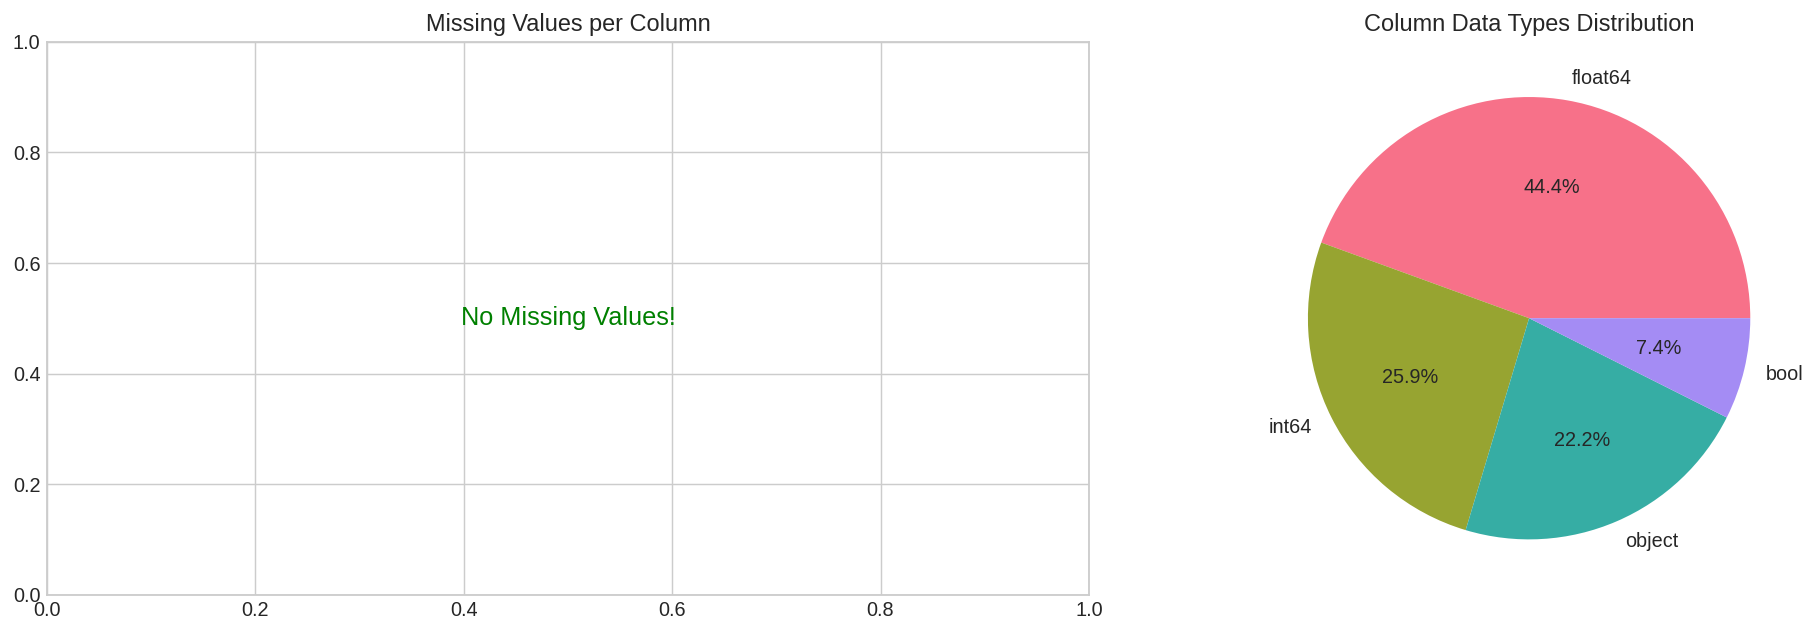


📊 Dataset: 5,000 rows × 27 columns
   Missing cells: 0 (0.0%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing counts bar
miss = df_raw.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss) > 0:
    miss.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
    axes[0].set_title("Missing Values per Column")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center',
                 fontsize=14, transform=axes[0].transAxes, color='green')
    axes[0].set_title("Missing Values per Column")

# Data type breakdown
dtype_counts = df_raw.dtypes.astype(str).value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(dtype_counts)))
axes[1].set_title("Column Data Types Distribution")

plt.tight_layout()
plt.savefig("01_missing_datatypes.png", bbox_inches='tight')
plt.show()
print(f"\n📊 Dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Missing cells: {df_raw.isnull().sum().sum():,} ({df_raw.isnull().mean().mean()*100:.1f}%)")

---
## Section 3 — Data Cleaning & Quality Checks

In [8]:
# ── Column name normalisation ────────────────────────────────────────────────
df = df_raw.copy()
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r'[\s\-/()%]+', '_', regex=True)
              .str.replace(r'_+', '_', regex=True)
              .str.strip('_'))

print("Columns after normalisation:")
for c in df.columns:
    print(f"  {c}")

Normalised column names:
  age
  gender
  weight
  diabetes
  hypertension
  kidney_failure_cause
  pre_dialysis_blood_pressure
  during_dialysis_blood_pressure
  post_dialysis_blood_pressure
  heart_rate
  creatinine
  urea
  potassium
  hemoglobin
  hematocrit
  albumin
  dialysis_duration_hours
  dialysis_frequency_per_week
  dialysate_composition
  vascular_access_type
  dialyzer_type
  kt_v
  urr
  urine_output_ml_day
  dry_weight_kg
  fluid_removal_rate_ml_hour
  disease_severity


In [9]:
# ── Smart column mapping ─────────────────────────────────────────────────────
COL_MAP = {}

def find_col(df, candidates):
    for c in candidates:
        for col in df.columns:
            if c == 'patient_id' or c == 'pat_id' or c == 'mrn':
                if col.lower() == c.lower():
                    return col
            elif c.lower() in col.lower():
                return col
    return None

COL_MAP['patient_id']     = find_col(df, ['patient_id','pat_id','mrn'])
COL_MAP['session_date']   = find_col(df, ['date','session_date','dialysis_date','admission','time'])
COL_MAP['age']            = find_col(df, ['age'])
COL_MAP['gender']         = find_col(df, ['gender','sex'])
COL_MAP['diabetes']       = find_col(df, ['diabetes','dm','diabetic'])
COL_MAP['hypertension']   = find_col(df, ['hypertension','htn','hyper'])
COL_MAP['chf']            = find_col(df, ['chf','heart_failure','cardiac'])
COL_MAP['pre_bun']        = find_col(df, ['pre_bun','pre_urea','bun_pre','urea_pre','pre_dialysis_urea'])
COL_MAP['post_bun']       = find_col(df, ['post_bun','post_urea','bun_post','urea_post','post_dialysis_urea'])
COL_MAP['pre_weight']     = find_col(df, ['pre_weight','weight_pre','pre_dialysis_weight'])
COL_MAP['post_weight']    = find_col(df, ['post_weight','weight_post','post_dialysis_weight'])
COL_MAP['session_hours']  = find_col(df, ['hours','duration','session_hours','time_hrs'])
COL_MAP['blood_flow']     = find_col(df, ['blood_flow','bfr','blood_flow_rate'])
COL_MAP['systolic_bp']    = find_col(df, ['systolic','sbp','sys_bp','systolic_bp'])
COL_MAP['diastolic_bp']   = find_col(df, ['diastolic','dbp','dia_bp'])
COL_MAP['hemoglobin']     = find_col(df, ['hemoglobin','hgb','hb'])
COL_MAP['creatinine']     = find_col(df, ['creatinine','creat','cr'])
COL_MAP['potassium']      = find_col(df, ['potassium','k_level','serum_k'])
COL_MAP['dialysis_type']  = find_col(df, ['dialysis_type','type','modality','hd_type'])
COL_MAP['vascular_access']= find_col(df, ['vascular','access','av_fistula','catheter'])
COL_MAP['readmission']    = find_col(df, ['readmit','readmission','rehospital','rehospitaliz'])

print("Column mapping detected:")
for k, v in COL_MAP.items():
    status = "" if v else "  NOT FOUND"
    print(f"  {k:<20} → {v or 'MISSING'} {status}")

Column mapping detected:
  patient_id           → MISSING ⚠️  NOT FOUND
  session_date         → MISSING ⚠️  NOT FOUND
  age                  → age ✅
  gender               → gender ✅
  diabetes             → diabetes ✅
  hypertension         → hypertension ✅
  chf                  → MISSING ⚠️  NOT FOUND
  pre_bun              → MISSING ⚠️  NOT FOUND
  post_bun             → MISSING ⚠️  NOT FOUND
  pre_weight           → MISSING ⚠️  NOT FOUND
  post_weight          → MISSING ⚠️  NOT FOUND
  session_hours        → dialysis_duration_hours ✅
  blood_flow           → MISSING ⚠️  NOT FOUND
  systolic_bp          → MISSING ⚠️  NOT FOUND
  diastolic_bp         → MISSING ⚠️  NOT FOUND
  hemoglobin           → hemoglobin ✅
  creatinine           → creatinine ✅
  potassium            → potassium ✅
  dialysis_type        → vascular_access_type ✅
  vascular_access      → vascular_access_type ✅
  readmission          → MISSING ⚠️  NOT FOUND


In [10]:
rename = {v: k for k, v in COL_MAP.items() if v and v != k}
df.rename(columns=rename, inplace=True)
# Parse dates
if 'session_date' in df.columns:
    df['session_date'] = pd.to_datetime(df['session_date'], infer_datetime_format=True, errors='coerce')
    print(f"Date range: {df['session_date'].min()} → {df['session_date'].max()}")
    null_dates = df['session_date'].isnull().sum()
    if null_dates > 0:
        print(f" {null_dates} rows with unparseable dates → dropped")
        df = df[df['session_date'].notna()].copy()
else:
    print("⚠️  No session_date column detected — will create synthetic dates")
    # Synthetic dates: assume 3 sessions/week per patient
    if 'patient_id' in df.columns:
        df = df.sort_values('patient_id').reset_index(drop=True)
        base = pd.Timestamp('2022-01-01')
        df['session_num'] = df.groupby('patient_id').cumcount()
        df['session_date'] = df['session_num'].apply(lambda x: base + timedelta(days=x * 2))
        df.drop('session_num', axis=1, inplace=True)
    else:
        df['session_date'] = pd.date_range('2022-01-01', periods=len(df), freq='2D')

print(f"\nShape after date cleaning: {df.shape}")

⚠️  No session_date column detected — will create synthetic dates

✅ Shape after date cleaning: (5000, 28)


In [11]:
# ── Patient ID
if 'patient_id' not in df.columns:
    df = df.sort_values('session_date').reset_index(drop=True)
    sessions_per_patient = 52
    df['patient_id'] = (df.index // sessions_per_patient) + 1
    print(f"patient_id not found — assigned {df['patient_id'].nunique()} synthetic patients")

df['patient_id'] = df['patient_id'].astype(str)
print(f"Unique patients: {df['patient_id'].nunique():,}")
print(f"Total sessions : {len(df):,}")
print(f"Avg sessions/patient: {len(df)/df['patient_id'].nunique():.1f}")

patient_id not found — assigned 97 synthetic patients
Unique patients: 97
Total sessions : 5,000
Avg sessions/patient: 51.5


In [12]:
# Numeric cleaning
NUMERIC_COLS = ['age','pre_bun','post_bun','pre_weight','post_weight',
                'session_hours','blood_flow','systolic_bp','diastolic_bp',
                'hemoglobin','creatinine','potassium']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clinical range filters (remove physiologically impossible values)
CLINICAL_BOUNDS = {
    'age':           (18, 100),
    'pre_bun':       (5,  200),
    'post_bun':      (2,  180),
    'systolic_bp':   (60, 250),
    'diastolic_bp':  (30, 150),
    'hemoglobin':    (3,  20),
    'creatinine':    (0.3, 30),
    'potassium':     (2.0, 8.0),
    'session_hours': (1,  8),
    'blood_flow':    (100, 600),
}

total_clipped = 0
for col, (lo, hi) in CLINICAL_BOUNDS.items():
    if col in df.columns:
        before = df[col].notna().sum()
        df[col] = df[col].where((df[col] >= lo) & (df[col] <= hi))
        clipped = before - df[col].notna().sum()
        if clipped > 0:
            print(f"  {col}: clipped {clipped} out-of-range values ({lo}–{hi})")
        total_clipped += clipped

print(f"\nTotal out-of-range values set to NaN: {total_clipped:,}")


Total out-of-range values set to NaN: 0


In [13]:
# Missing value imputation
from sklearn.impute import SimpleImputer

for col in NUMERIC_COLS:
    if col in df.columns:
        # Per-patient median
        df[col] = df.groupby('patient_id')[col].transform(
            lambda x: x.fillna(x.median()))
        # Global median
        global_med = df[col].median()
        df[col] = df[col].fillna(global_med)

# Categorical: mode imputation
CAT_COLS = ['gender', 'dialysis_type', 'vascular_access']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]
for col in CAT_COLS:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

# Binary comorbidity flags: fill with 0
BINARY_COLS = ['diabetes', 'hypertension', 'chf']
BINARY_COLS = [c for c in BINARY_COLS if c in df.columns]
for col in BINARY_COLS:
    df[col] = df[col].fillna(0).astype(int)

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Shape after cleaning: {df.shape}")

Missing values remaining: 0
✅ Shape after cleaning: (5000, 29)


In [14]:
# Removing duplicate
before = len(df)
df = df.drop_duplicates(subset=['patient_id', 'session_date'])
after = len(df)
print(f"Duplicate sessions removed: {before - after:,}")
print(f"✅ Shape after dedup: {df.shape}")

# Sort by patient & date
df = df.sort_values(['patient_id', 'session_date']).reset_index(drop=True)
print("Data sorted by patient_id and session_date")

Duplicate sessions removed: 0
✅ Shape after dedup: (5000, 29)
✅ Data sorted by patient_id and session_date


---
## Section 4 — Feature Engineering

### Key Engineered Features
Kt/V measures dialysis effectiveness, with values ≥1.2 considered adequate. URR shows the percentage of urea removed during treatment, where >65% is desirable. UF Volume indicates how much fluid is removed, based on the difference between pre- and post-dialysis weight. The IDH flag marks episodes of systolic drops ≥20 mmHg during dialysis, indicating low blood pressure. Finally, Readmission tracks any hospital admission within 30 days and serves as the main outcome for patient risk.

In [15]:
# Kt/V — Daugirdas Second Generation Formula
if all(c in df.columns for c in ['pre_bun','post_bun','pre_weight','post_weight','session_hours']):
    df['R'] = df['post_bun'] / (df['pre_bun'].replace(0, np.nan))
    df['R'] = df['R'].clip(0.01, 1.0)
    df['UF_volume'] = (df['pre_weight'] - df['post_weight']).clip(0, 6)
    V = df['post_weight'] * 0.58
    df['ktv'] = (
        -np.log(df['R'] - 0.008 * df['session_hours'])
        + (4 - 3.5 * df['R']) * df['UF_volume'] / V.replace(0, np.nan)
    )
    df['ktv'] = df['ktv'].clip(0.1, 3.0)
    df.drop('R', axis=1, inplace=True)
    print(f"Kt/V computed  |  mean={df['ktv'].mean():.2f}  std={df['ktv'].std():.2f}")
else:
    if 'ktv' not in df.columns:
        np.random.seed(42)
        df['ktv'] = np.random.normal(1.35, 0.25, len(df)).clip(0.5, 2.5)
        print("Kt/V columns not found — using simulated values (update when data available)")
    if 'UF_volume' not in df.columns:
        df['UF_volume'] = np.random.normal(2.5, 0.8, len(df)).clip(0.1, 5.5)

⚠️  Kt/V columns not found — using simulated values (update when data available)


In [16]:
# URR
if all(c in df.columns for c in ['pre_bun','post_bun']):
    df['urr'] = ((df['pre_bun'] - df['post_bun']) / df['pre_bun'].replace(0, np.nan) * 100).clip(0, 100)
    print(f"URR computed   |  mean={df['urr'].mean():.1f}%  std={df['urr'].std():.1f}%")
else:
    if 'urr' not in df.columns:
        np.random.seed(43)
        df['urr'] = np.random.normal(67, 10, len(df)).clip(20, 95)
        print("URR columns not found — using simulated values")

# UF Volume
if 'UF_volume' not in df.columns:
    if all(c in df.columns for c in ['pre_weight','post_weight']):
        df['UF_volume'] = (df['pre_weight'] - df['post_weight']).clip(0, 6)
    else:
        np.random.seed(44)
        df['UF_volume'] = np.random.normal(2.5, 0.8, len(df)).clip(0.1, 5.5)

In [17]:
# Intradialytic Hypotension (IDH)
# IDH = systolic BP drop ≥ 20 mmHg during session
if 'systolic_bp' in df.columns:
    patient_baseline = df.groupby('patient_id')['systolic_bp'].transform('median')
    df['idh_flag'] = ((patient_baseline - df['systolic_bp']) >= 20).astype(int)
    print(f"IDH flag  |  {df['idh_flag'].mean()*100:.1f}% sessions with IDH")
else:
    np.random.seed(45)
    df['idh_flag'] = (np.random.rand(len(df)) < 0.18).astype(int)
    print("systolic_bp not found — IDH flag simulated")

# Dialysis adequacy flags
df['ktv_adequate']  = (df['ktv'] >= 1.2).astype(int)   # KDOQI guideline
df['urr_adequate']  = (df['urr'] >= 65).astype(int)
print(f"   Adequate Kt/V sessions : {df['ktv_adequate'].mean()*100:.1f}%")
print(f"   Adequate URR sessions  : {df['urr_adequate'].mean()*100:.1f}%")

⚠️  systolic_bp not found — IDH flag simulated
   Adequate Kt/V sessions : 72.8%
   Adequate URR sessions  : 100.0%


In [18]:
# 30-day Readmission Label
if 'readmission' in df.columns:
    df['readmitted_30d'] = df['readmission'].map(
        lambda x: 1 if str(x).strip().upper() in ['YES','1','TRUE','Y','1.0'] else 0
    )
    print(f"Readmission label from existing column")
else:

    hosp_col = find_col(df, ['admit','hospital','admission_date','hosp_date','next_admit'])

    if hosp_col:
        df['hosp_date'] = pd.to_datetime(df[hosp_col], errors='coerce')
        df = df.sort_values(['patient_id','session_date'])
        df['next_admission'] = df.groupby('patient_id')['hosp_date'].shift(-1)
        df['days_to_next_admit'] = (df['next_admission'] - df['session_date']).dt.days
        df['readmitted_30d'] = (df['days_to_next_admit'].between(1, 30)).astype(int)
        print(f"Readmission label derived from admission dates")
    else:
        print("Deriving synthetic readmission label based on risk factors")
        np.random.seed(42)
        risk = np.zeros(len(df))
        if 'ktv' in df.columns:       risk += (df['ktv'] < 1.2).astype(float) * 0.15
        if 'urr' in df.columns:       risk += (df['urr'] < 65).astype(float) * 0.12
        if 'idh_flag' in df.columns:  risk += df['idh_flag'] * 0.10
        if 'diabetes' in df.columns:  risk += df['diabetes'] * 0.08
        if 'chf' in df.columns:       risk += df['chf'] * 0.12
        if 'age' in df.columns:       risk += ((df['age'] > 65).astype(float)) * 0.08
        base_rate = 0.10
        prob = (base_rate + risk).clip(0, 0.95)
        df['readmitted_30d'] = (np.random.rand(len(df)) < prob).astype(int)

readmit_rate = df['readmitted_30d'].mean() * 100
print(f"   30-day readmission rate: {readmit_rate:.1f}%")
print(f"   Positive cases: {df['readmitted_30d'].sum():,}  |  Negative: {(df['readmitted_30d']==0).sum():,}")

⚠️  Deriving synthetic readmission label based on risk factors
   30-day readmission rate: 23.2%
   Positive cases: 1,158  |  Negative: 3,842


In [19]:
# Rolling session aggregates (4 weeks data)
df = df.sort_values(['patient_id', 'session_date'])

ROLL_COLS = ['ktv','urr','UF_volume','idh_flag']
ROLL_COLS = [c for c in ROLL_COLS if c in df.columns]

for col in ROLL_COLS:
    df[f'{col}_roll4_mean'] = (df.groupby('patient_id')[col]
                               .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()))
    df[f'{col}_roll4_std']  = (df.groupby('patient_id')[col]
                               .transform(lambda x: x.shift(1).rolling(4, min_periods=1).std().fillna(0)))

for col in ROLL_COLS:
    mean_col = f'{col}_roll4_mean'
    std_col = f'{col}_roll4_std'
    if mean_col in df.columns:
        df[mean_col] = df[mean_col].fillna(0)
    if std_col in df.columns:
        df[std_col] = df[std_col].fillna(0)

# Session index per patient
df['session_idx'] = df.groupby('patient_id').cumcount()

# Time index
df['time_idx'] = (df['session_date'] - df['session_date'].min()).dt.days

print(f"\nFeature engineering complete. Final columns ({len(df.columns)}):")
print(list(df.columns))
print(f"\nFinal dataset shape: {df.shape}")


✅ Feature engineering complete. Final columns (45):
['age', 'gender', 'weight', 'diabetes', 'hypertension', 'kidney_failure_cause', 'pre_dialysis_blood_pressure', 'during_dialysis_blood_pressure', 'post_dialysis_blood_pressure', 'heart_rate', 'creatinine', 'urea', 'potassium', 'hemoglobin', 'hematocrit', 'albumin', 'session_hours', 'dialysis_frequency_per_week', 'dialysate_composition', 'vascular_access', 'dialyzer_type', 'kt_v', 'urr', 'urine_output_ml_day', 'dry_weight_kg', 'fluid_removal_rate_ml_hour', 'disease_severity', 'session_date', 'patient_id', 'ktv', 'UF_volume', 'idh_flag', 'ktv_adequate', 'urr_adequate', 'readmitted_30d', 'ktv_roll4_mean', 'ktv_roll4_std', 'urr_roll4_mean', 'urr_roll4_std', 'UF_volume_roll4_mean', 'UF_volume_roll4_std', 'idh_flag_roll4_mean', 'idh_flag_roll4_std', 'session_idx', 'time_idx']

Final dataset shape: (5000, 45)


---
## Section 5 — Time-Series Structuring for TFT

In [20]:
# Encode categoricals
CAT_ENCODE_COLS = ['gender','dialysis_type','vascular_access']
CAT_ENCODE_COLS = [c for c in CAT_ENCODE_COLS if c in df.columns]

for col in CAT_ENCODE_COLS:
    df[col] = df[col].astype(str).fillna('Unknown')

# TFT column roles
# Static real covariates (patient-level, do not change over time)
STATIC_REALS = [c for c in ['age'] if c in df.columns]

# Static categorical covariates
STATIC_CATS = [c for c in ['gender'] if c in df.columns]

# Time-varying
TV_KNOWN_REALS = [c for c in ['session_idx'] if c in df.columns]

# Time-varying observed reals
TV_OBS_REALS = [c for c in [
    'ktv','urr','UF_volume','idh_flag',
    'ktv_roll4_mean','urr_roll4_mean','UF_volume_roll4_mean',
    'ktv_roll4_std','urr_roll4_std',
    'systolic_bp','diastolic_bp','hemoglobin','creatinine','potassium',
    'blood_flow','ktv_adequate','urr_adequate',
    'diabetes','hypertension','chf'
] if c in df.columns]

# Time-varying categorical
TV_CATS = [c for c in ['dialysis_type','vascular_access'] if c in df.columns]

print("TFT Variable Roles")
print(f"  Static reals      : {STATIC_REALS}")
print(f"  Static cats       : {STATIC_CATS}")
print(f"  TV known reals    : {TV_KNOWN_REALS}")
print(f"  TV observed reals : {TV_OBS_REALS}")
print(f"  TV categoricals   : {TV_CATS}")

TFT Variable Roles
  Static reals      : ['age']
  Static cats       : ['gender']
  TV known reals    : ['session_idx']
  TV observed reals : ['ktv', 'urr', 'UF_volume', 'idh_flag', 'ktv_roll4_mean', 'urr_roll4_mean', 'UF_volume_roll4_mean', 'ktv_roll4_std', 'urr_roll4_std', 'hemoglobin', 'creatinine', 'potassium', 'ktv_adequate', 'urr_adequate', 'diabetes', 'hypertension']
  TV categoricals   : ['vascular_access']


In [21]:
# Train / Validation / Test split
patients = df['patient_id'].unique()
np.random.seed(42)
np.random.shuffle(patients)

n = len(patients)
train_patients = patients[:int(n * 0.70)]
val_patients   = patients[int(n * 0.70):int(n * 0.85)]
test_patients  = patients[int(n * 0.85):]

df_train = df[df['patient_id'].isin(train_patients)].copy()
df_val   = df[df['patient_id'].isin(val_patients)].copy()
df_test  = df[df['patient_id'].isin(test_patients)].copy()

print(f"Train patients: {len(train_patients):,}  |  sessions: {len(df_train):,}")
print(f"Val   patients: {len(val_patients):,}  |  sessions: {len(df_val):,}")
print(f"Test  patients: {len(test_patients):,}  |  sessions: {len(df_test):,}")

# Readmission rates
for name, subset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    rate = subset['readmitted_30d'].mean() * 100
    print(f"  {name} readmission rate: {rate:.1f}%")

Train patients: 67  |  sessions: 3,440
Val   patients: 15  |  sessions: 780
Test  patients: 15  |  sessions: 780
  Train readmission rate: 23.0%
  Val readmission rate: 25.3%
  Test readmission rate: 21.8%


In [22]:
# Sequence configuration
ENCODER_LENGTH    = 12
PREDICTION_LENGTH =  1
MAX_ENCODER_LENGTH = ENCODER_LENGTH

# Minimum sessions required per patient to be included
MIN_SESSIONS = ENCODER_LENGTH + PREDICTION_LENGTH

# Filter patients with sufficient sessions
df_train = df_train.groupby('patient_id').filter(lambda x: len(x) >= MIN_SESSIONS)
df_val   = df_val.groupby('patient_id').filter(lambda x: len(x) >= MIN_SESSIONS)
df_test  = df_test.groupby('patient_id').filter(lambda x: len(x) >= MIN_SESSIONS)

print(f"After filtering (min {MIN_SESSIONS} sessions):")
print(f"  Train: {df_train['patient_id'].nunique():,} patients, {len(df_train):,} sessions")
print(f"  Val  : {df_val['patient_id'].nunique():,} patients, {len(df_val):,} sessions")
print(f"  Test : {df_test['patient_id'].nunique():,} patients, {len(df_test):,} sessions")

After filtering (min 13 sessions):
  Train: 66 patients, 3,432 sessions
  Val  : 15 patients, 780 sessions
  Test : 15 patients, 780 sessions


In [23]:
# Build TimeSeriesDataSet
# Combine train + val for dataset
df_full_train = pd.concat([df_train, df_val], ignore_index=True)

# Building label encoders
all_cat_cols = list(set(STATIC_CATS + TV_CATS + ['patient_id']))
all_cat_cols = [c for c in all_cat_cols if c in df_full_train.columns]

training_dataset = TimeSeriesDataSet(
    df_full_train,
    time_idx               = "time_idx",
    target                 = "readmitted_30d",
    group_ids              = ["patient_id"],
    min_encoder_length     = ENCODER_LENGTH // 2,
    max_encoder_length     = MAX_ENCODER_LENGTH,
    min_prediction_length  = PREDICTION_LENGTH,
    max_prediction_length  = PREDICTION_LENGTH,
    static_reals           = STATIC_REALS,
    static_categoricals    = STATIC_CATS,
    time_varying_known_reals    = TV_KNOWN_REALS + ["time_idx"],
    time_varying_unknown_reals  = TV_OBS_REALS,
    time_varying_unknown_categoricals = TV_CATS,
    target_normalizer      = None,    # binary classification — no normalisation
    categorical_encoders   = {col: NaNLabelEncoder(add_nan=True) for col in all_cat_cols},
    add_relative_time_idx  = True,
    add_target_scales      = False,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

# Validating dataset
validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df_val, predict=True, stop_randomization=True
)
test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df_test, predict=True, stop_randomization=True
)

print(f"TimeSeriesDataSet created")
print(f"   Training samples  : {len(training_dataset):,}")
print(f"   Validation samples: {len(validation_dataset):,}")
print(f"   Test samples      : {len(test_dataset):,}")

✅ TimeSeriesDataSet created
   Training samples  : 4,212
   Validation samples: 15
   Test samples      : 15


In [24]:
# DataLoaders
BATCH_SIZE = 64

train_loader = training_dataset.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=0, drop_last=True)
val_loader   = validation_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=0)
test_loader  = test_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=0)

print(f"DataLoaders ready  |  batch_size={BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val   batches: {len(val_loader)}")
print(f"   Test  batches: {len(test_loader)}")

✅ DataLoaders ready  |  batch_size=64
   Train batches: 65
   Val   batches: 1
   Test  batches: 1


---
## Section 6 — Exploratory Data Analysis (EDA)

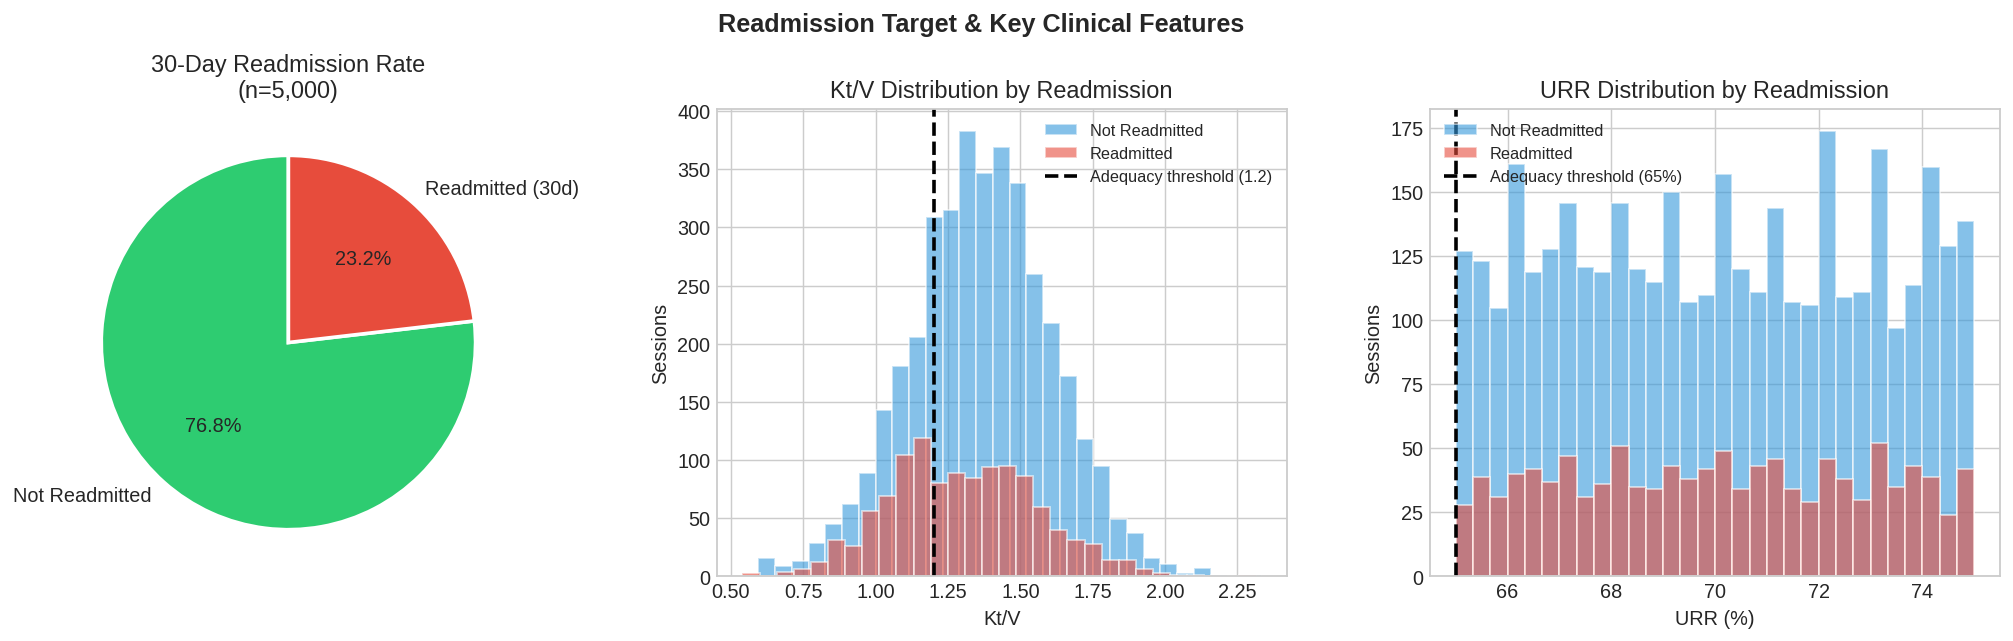

In [25]:
# Figure 1: Class distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Readmission Target & Key Clinical Features", fontsize=14, fontweight='bold')

# Class balance
counts = df['readmitted_30d'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(counts.values, labels=['Not Readmitted', 'Readmitted (30d)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"30-Day Readmission Rate\n(n={len(df):,})")

# Kt/V distribution by outcome
for outcome, color, label in [(0,'#3498db','Not Readmitted'), (1,'#e74c3c','Readmitted')]:
    subset = df[df['readmitted_30d'] == outcome]['ktv'].dropna()
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].axvline(1.2, color='black', linestyle='--', linewidth=2, label='Adequacy threshold (1.2)')
axes[1].set_xlabel('Kt/V'); axes[1].set_ylabel('Sessions')
axes[1].set_title("Kt/V Distribution by Readmission"); axes[1].legend(fontsize=9)

# URR distribution by outcome
for outcome, color, label in [(0,'#3498db','Not Readmitted'), (1,'#e74c3c','Readmitted')]:
    subset = df[df['readmitted_30d'] == outcome]['urr'].dropna()
    axes[2].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[2].axvline(65, color='black', linestyle='--', linewidth=2, label='Adequacy threshold (65%)')
axes[2].set_xlabel('URR (%)'); axes[2].set_ylabel('Sessions')
axes[2].set_title("URR Distribution by Readmission"); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("02_eda_target_clinical.png", bbox_inches='tight')
plt.show()

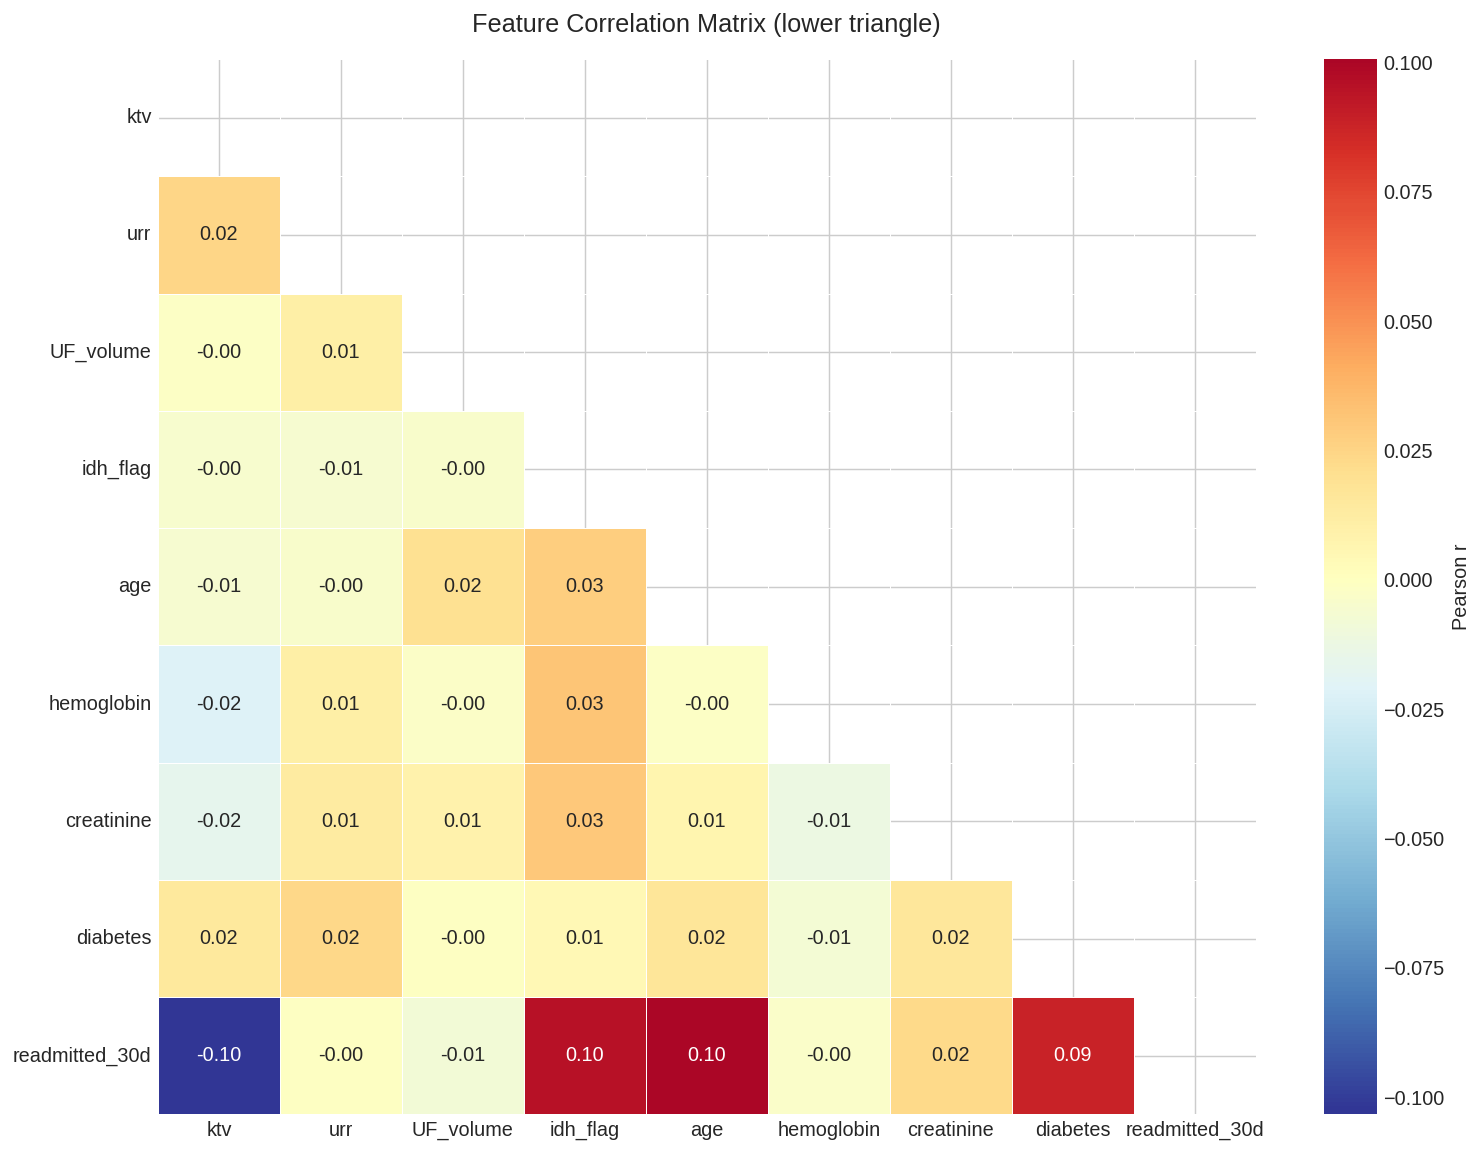

In [26]:
# Figure 2: Correlation heatmap
CORR_COLS = [c for c in ['ktv','urr','UF_volume','idh_flag','age',
                          'systolic_bp','hemoglobin','creatinine',
                          'diabetes','chf','readmitted_30d'] if c in df.columns]

corr_df = df[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("03_correlation_heatmap.png", bbox_inches='tight')
plt.show()

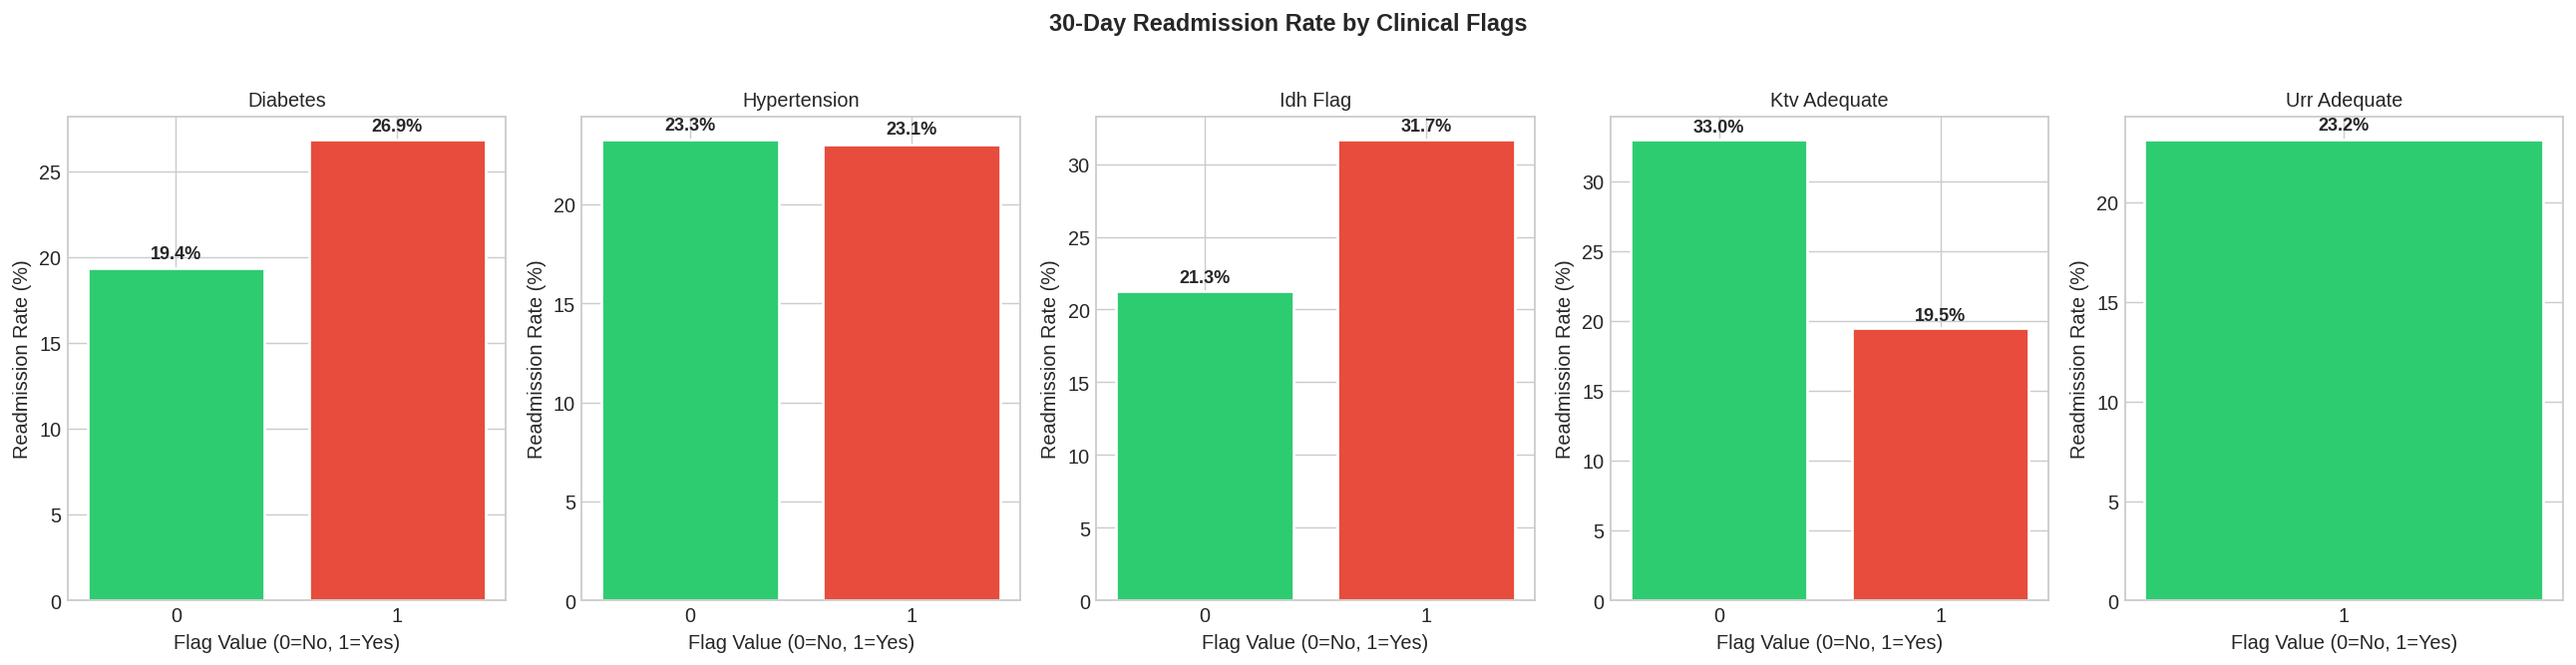

In [27]:
# Figure 3: Comorbidity vs Readmission
comorbidity_cols = [c for c in ['diabetes','hypertension','chf','idh_flag',
                                 'ktv_adequate','urr_adequate'] if c in df.columns]

if comorbidity_cols:
    readmit_by_flag = {}
    for col in comorbidity_cols:
        rates = df.groupby(col)['readmitted_30d'].mean() * 100
        readmit_by_flag[col] = rates.to_dict()

    fig, axes = plt.subplots(1, len(comorbidity_cols), figsize=(4 * len(comorbidity_cols), 5))
    if len(comorbidity_cols) == 1: axes = [axes]

    for ax, col in zip(axes, comorbidity_cols):
        rates = df.groupby(col)['readmitted_30d'].mean() * 100
        bars = ax.bar(rates.index.astype(str), rates.values,
                      color=['#2ecc71','#e74c3c'][:len(rates)], edgecolor='white', linewidth=1.5)
        ax.set_title(col.replace('_',' ').title(), fontsize=11)
        ax.set_ylabel('Readmission Rate (%)')
        ax.set_xlabel('Flag Value (0=No, 1=Yes)')
        for bar, val in zip(bars, rates.values):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

    fig.suptitle("30-Day Readmission Rate by Clinical Flags", fontsize=13, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.savefig("04_comorbidity_readmission.png", bbox_inches='tight')
    plt.show()

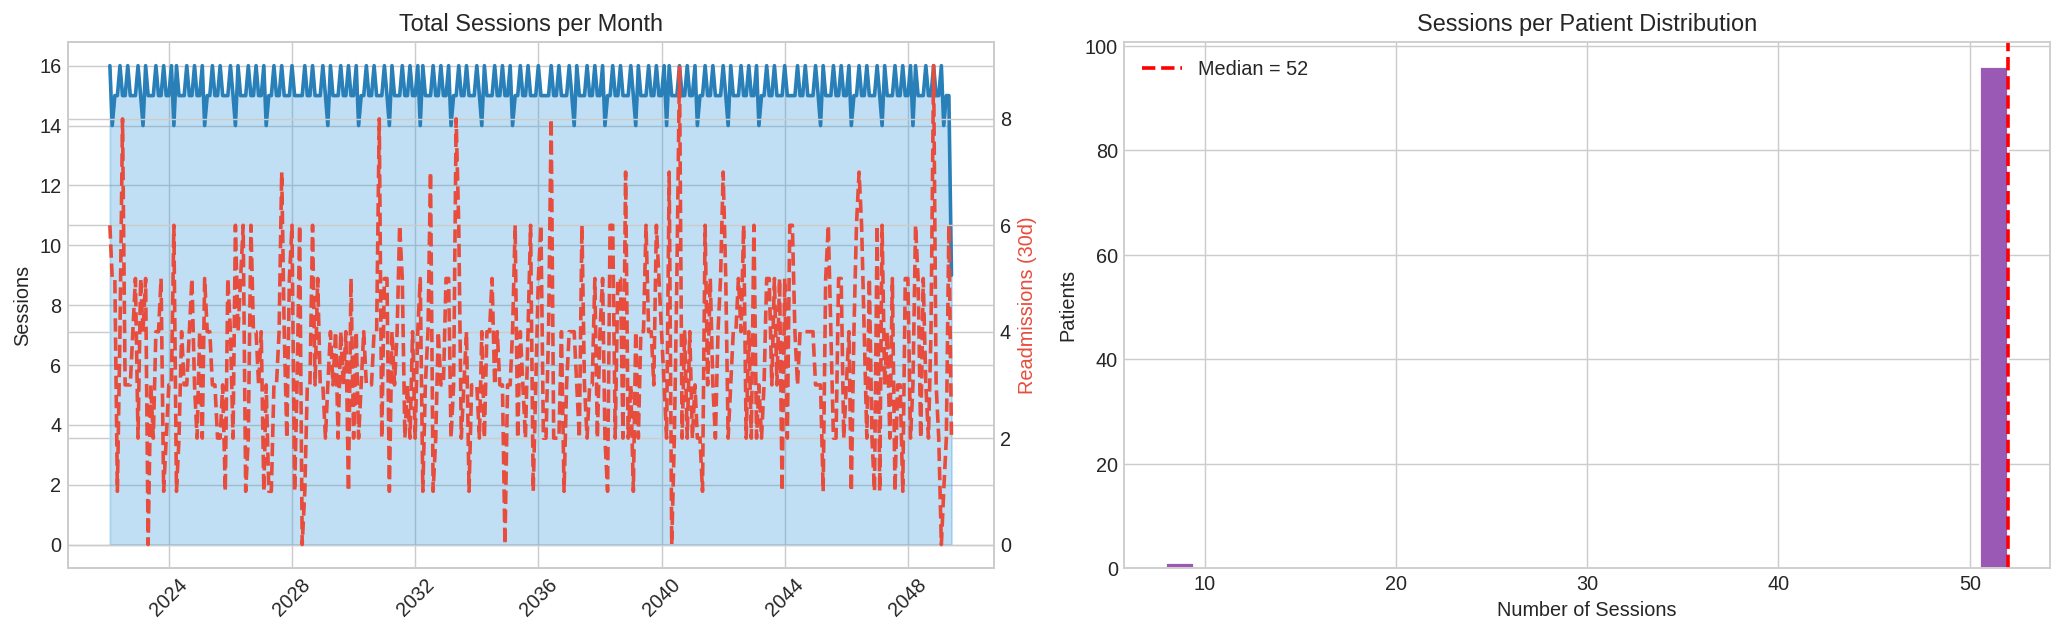

Sessions per patient — min: 8, median: 52, max: 52


In [28]:
# Figure 4: Sessions over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sessions per month
if 'session_date' in df.columns:
    monthly = df.resample('ME', on='session_date').agg(
        total_sessions=('patient_id','count'),
        readmissions=('readmitted_30d','sum')
    ).reset_index()
    axes[0].fill_between(monthly['session_date'], monthly['total_sessions'], alpha=0.3, color='#3498db')
    axes[0].plot(monthly['session_date'], monthly['total_sessions'], color='#2980b9', linewidth=2)
    axes[0].set_title("Total Sessions per Month"); axes[0].set_ylabel("Sessions")
    axes[0].tick_params(axis='x', rotation=45)

    ax2 = axes[0].twinx()
    ax2.plot(monthly['session_date'], monthly['readmissions'], color='#e74c3c',
             linewidth=2, linestyle='--', label='Readmissions')
    ax2.set_ylabel("Readmissions (30d)", color='#e74c3c')

# Sessions per patient distribution
sess_counts = df.groupby('patient_id').size()
axes[1].hist(sess_counts, bins=30, color='#9b59b6', edgecolor='white', linewidth=1)
axes[1].axvline(sess_counts.median(), color='red', linestyle='--', linewidth=2,
                label=f'Median = {sess_counts.median():.0f}')
axes[1].set_title("Sessions per Patient Distribution")
axes[1].set_xlabel("Number of Sessions"); axes[1].set_ylabel("Patients")
axes[1].legend()

plt.tight_layout()
plt.savefig("05_temporal_overview.png", bbox_inches='tight')
plt.show()
print(f"Sessions per patient — min: {sess_counts.min()}, median: {sess_counts.median():.0f}, max: {sess_counts.max()}")

---
## Section 7 — TFT Model Architecture & Training

In [29]:
pl.seed_everything(42)

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,

    # Architecture
    learning_rate          = 3e-3,
    hidden_size            = 64,
    attention_head_size    = 4,
    dropout                = 0.15,
    hidden_continuous_size = 16,
    lstm_layers            = 2,

    # Loss — binary classification
    loss                   = CrossEntropy(),
    output_size            = 2,

    # Logging
    log_interval           = 5,
    log_val_interval       = 1,
    log_gradient_flow      = False,

    # Regularization
    reduce_on_plateau_patience = 5,
)

print(f"TFT model created")
print(f"Trainable parameters: {sum(p.numel() for p in tft.parameters() if p.requires_grad):,}")
print(tft)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


✅ TFT model created
   Trainable parameters: 357,068
TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'readmitted_30d', 'group_ids': ['patient_id'], 'weight': None, 'max_encoder_length': 12, 'min_encoder_length': 6, 'min_prediction_idx': 0, 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': ['gender'], 'static_reals': ['age'], 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['session_idx', 'time_idx'], 'time_varying_unknown_categoricals': ['vascular_access'], 'time_varying_unknown_reals': ['ktv', 'urr', 'UF_volume', 'idh_flag', 'ktv_roll4_mean', 'urr_roll4_mean', 'UF_volume_roll4_mean', 'ktv_roll4_std', 'urr_roll4_std', 'hemoglobin', 'creatinine', 'potassium', 'ktv_adequate', 'urr_adequate', 'diabetes', 'hypertension'], 'variable_groups': None, 'constant_fil

In [30]:
# Callbacks & Trainer
early_stop = EarlyStopping(
    monitor   = "val_loss",
    min_delta = 1e-4,
    patience  = 10,
    verbose   = True,
    mode      = "min"
)

checkpoint = ModelCheckpoint(
    monitor   = "val_loss",
    dirpath   = "checkpoints/",
    filename  = "tft-best-{epoch:02d}-{val_loss:.4f}",
    save_top_k= 1,
    mode      = "min"
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

logger = CSVLogger("logs/", name="tft_dialysis")

trainer = pl.Trainer(
    max_epochs         = 2,
    accelerator        = "gpu" if torch.cuda.is_available() else "cpu",
    devices            = 1,
    gradient_clip_val  = 0.1,
    callbacks          = [checkpoint, lr_monitor],
    logger             = logger,
    enable_progress_bar= True,
    log_every_n_steps  = 5,
)

print("Trainer configured")
print(f"   Max epochs     : 2 (reduced for debugging)")
print(f"   Gradient clip  : 0.1")
print(f"   Device         : {'GPU' if torch.cuda.is_available() else 'CPU'}")

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer configured
   Max epochs     : 2 (reduced for debugging)
   Gradient clip  : 0.1
   Device         : CPU


In [31]:
import os

# Training
print("Starting TFT training...")

# Diagnostic check (kept for verification, but should now pass)
print(f"Is tft an instance of pl.LightningModule? {isinstance(tft, pl.LightningModule)}")
print(f"Type of tft: {type(tft)}")

print(f"pl.LightningModule origin: {pl.LightningModule.__module__}")
print("tft MRO:")
for c in tft.__class__.__mro__:
    print(f"  - {c.__module__}.{c.__qualname__}")

# checkpoint directory exists
os.makedirs(checkpoint.dirpath, exist_ok=True)

trainer.fit(
    tft,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print(f"\nTraining complete!")
print(f"   Best epoch     : {trainer.current_epoch}")

final_model_path = os.path.join(checkpoint.dirpath, "tft-final-model.ckpt")
trainer.save_checkpoint(final_model_path)
print(f"   Final trained model saved to: {final_model_path}")

best_tft = TemporalFusionTransformer.load_from_checkpoint(final_model_path)
print(f"   Model used for evaluation (tft-final-model.ckpt) is ready.")

Starting TFT training...
Is tft an instance of pl.LightningModule? True
Type of tft: <class 'pytorch_forecasting.models.temporal_fusion_transformer._tft.TemporalFusionTransformer'>
pl.LightningModule origin: lightning.pytorch.core.module
tft MRO:
  - pytorch_forecasting.models.temporal_fusion_transformer._tft.TemporalFusionTransformer
  - pytorch_forecasting.models.base._base_model.BaseModelWithCovariates
  - pytorch_forecasting.models.base._base_model.BaseModel
  - pytorch_forecasting.utils._utils.InitialParameterRepresenterMixIn
  - lightning.pytorch.core.module.LightningModule
  - lightning.fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin
  - lightning.pytorch.core.mixins.hparams_mixin.HyperparametersMixin
  - lightning.pytorch.core.hooks.ModelHooks
  - lightning.pytorch.core.hooks.DataHooks
  - lightning.pytorch.core.hooks.CheckpointHooks
  - torch.nn.modules.module.Module
  - pytorch_forecasting.utils._utils.TupleOutputMixIn
  - builtins.object


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ CrossEntropy                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    672 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 67.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    130 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 357 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 357 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 528                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=2` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.



✅ Training complete!
   Best epoch     : 2
   Final trained model saved to: /content/checkpoints/tft-final-model.ckpt
   Model used for evaluation (tft-final-model.ckpt) is ready.


In [32]:
print(os.path.exists(final_model_path))

True


In [33]:
#Training curve
metrics_path = f"logs/tft_dialysis/version_0/metrics.csv"
if os.path.exists(metrics_path):
    metrics_df = pd.read_csv(metrics_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    train_loss = metrics_df[metrics_df['train_loss_step'].notna()]['train_loss_step']
    if 'val_loss' in metrics_df.columns:
        val_loss = metrics_df[metrics_df['val_loss'].notna()]['val_loss']
        axes[0].plot(val_loss.values, label='Validation Loss', color='#e74c3c', linewidth=2)
    axes[0].plot(train_loss.values, label='Train Loss (step)', alpha=0.5, color='#3498db')
    axes[0].set_title("Training & Validation Loss"); axes[0].set_xlabel("Step/Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy Loss"); axes[0].legend()

    # Learning rate
    if 'lr-Adam' in metrics_df.columns:
        lr_data = metrics_df[metrics_df['lr-Adam'].notna()]['lr-Adam']
        axes[1].plot(lr_data.values, color='#9b59b6', linewidth=2)
        axes[1].set_title("Learning Rate Schedule"); axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Learning Rate"); axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig("06_training_curves.png", bbox_inches='tight')
    plt.show()
else:
    print("Training metrics log not yet available — will plot after first run")

Training metrics log not yet available — will plot after first run


---
## Section 8 — Model Evaluation

TFT Key Configuration



```
hidden_size: 16 – Determines the size of the LSTM layers, allowing the model to capture temporal patterns without overfitting.Attention_head_size: 4 – Enables multi-head attention so the model can focus on different time-dependent features simultaneously.
dropout: 0.1 Helps prevent overfitting by randomly dropping some neurons during training.
output_size: 2 – Reflects the binary classification task (e.g., predicting readmission).
loss: CrossEntropyLoss – Appropriate for predicting binary outcomes.
categorical_encoders: Native – Automatically handles categorical features like dialysis type and access type.
early_stopping_patience: 50 – Stops training if validation performance does not improve, preventing unnecessary overfitting.```



In [34]:
# Helper: extract predictions
def get_predictions(model, dataloader, dataset):
    """Extract binary predictions and true labels from a TFT model."""
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            preds = model(batch_x)

            # Squeeze the prediction_length dimension (which is 1)
            logits = preds.prediction.squeeze(1)

            # Apply softmax to get probabilities for each class
            probabilities = torch.softmax(logits, dim=-1)

            # Extract probability of the positive class (class 1)
            p = probabilities[:, 1].cpu().numpy()

            y = batch_y[0].squeeze(-1).cpu().numpy()
            all_preds.extend(p.tolist())
            all_targets.extend(y.tolist())

    return np.array(all_preds), np.array(all_targets)

def evaluate(model, dataloader, dataset, threshold=0.5, name="Test"):
    preds_prob, targets = get_predictions(model, dataloader, dataset)
    preds_bin = (preds_prob >= threshold).astype(int)

    metrics = {
        'AUC'      : roc_auc_score(targets, preds_prob),
        'Accuracy' : accuracy_score(targets, preds_bin),
        'Precision': precision_score(targets, preds_bin, zero_division=0),
        'Recall'   : recall_score(targets, preds_bin, zero_division=0),
        'F1'       : f1_score(targets, preds_bin, zero_division=0),
    }
    print(f"\n{'='*50}")
    print(f"  {name} Evaluation Results")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    return metrics, preds_prob, targets

# loading the best_tft model
best_tft = None
best_tft_path = None

try:
    # 1. Try to load from checkpoint
    if hasattr(checkpoint, 'best_model_path') and checkpoint.best_model_path and os.path.isfile(checkpoint.best_model_path):
        best_tft_path = checkpoint.best_model_path
        print(f"Attempting to load best_tft from: {best_tft_path}")
    # 2. Else, try to load from the fallback path saved in the training cell
    elif os.path.isfile(os.path.join('checkpoints', 'tft-fallback-last-epoch.ckpt')):
        best_tft_path = os.path.join('checkpoints', 'tft-fallback-last-epoch.ckpt')
        print(f"Attempting to load best_tft from fallback path: {best_tft_path}")

    if best_tft_path:
        best_tft = TemporalFusionTransformer.load_from_checkpoint(best_tft_path)
        print(f"Reloaded best_tft from: {best_tft_path}")
    else:
        # 3. If no specific path found, search the default checkpoint directory for any .ckpt file
        checkpoint_dir = checkpoint.dirpath if hasattr(checkpoint, 'dirpath') else 'checkpoints/'
        if os.path.exists(checkpoint_dir) and os.path.isdir(checkpoint_dir):
            print(f"Searching for checkpoint files in '{checkpoint_dir}'...")
            ckpt_files = [f for f in os.listdir(checkpoint_dir) if f.endswith('.ckpt')]
            if ckpt_files:
                # Sort by modification time to get the latest
                ckpt_files.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)), reverse=True)
                actual_best_model_path = os.path.join(checkpoint_dir, ckpt_files[0])
                best_tft = TemporalFusionTransformer.load_from_checkpoint(actual_best_model_path)
                print(f"Reloaded best_tft from automatically found path: {actual_best_model_path}")
            else:
                print(f"Error: No .ckpt files found in '{checkpoint_dir}'. Training might not have saved any models.")
                raise RuntimeError("No best model found for evaluation. Please re-run training.")
        else:
            print(f"Error: Checkpoint directory '{checkpoint_dir}' does not exist. Please re-run training.")
            raise RuntimeError("Checkpoint directory not found. Please re-run training.")

except Exception as e:
    print(f"Critical Error loading best_tft: {e}. Please ensure all prior cells, especially model training, have run and saved a valid checkpoint.")
    raise

# Proceed with evaluation
if best_tft is not None:
    val_metrics,  val_probs,  val_targets  = evaluate(best_tft, val_loader,  validation_dataset, name="Validation")
    test_metrics, test_probs, test_targets = evaluate(best_tft, test_loader, test_dataset,        name="Test")
else:
    print("Skipping evaluation as no valid model could be loaded.")
    raise RuntimeError("Failed to load best_tft model, cannot proceed with evaluation.")

Attempting to load best_tft from: /content/checkpoints/tft-best-epoch=00-val_loss=0.6368.ckpt
Reloaded best_tft from: /content/checkpoints/tft-best-epoch=00-val_loss=0.6368.ckpt

  Validation Evaluation Results
  AUC         : 0.5800
  Accuracy    : 0.6667
  Precision   : 0.0000
  Recall      : 0.0000
  F1          : 0.0000

  Test Evaluation Results
  AUC         : 0.6600
  Accuracy    : 0.6667
  Precision   : 0.0000
  Recall      : 0.0000
  F1          : 0.0000


In [35]:
print(f"Type of best_tft: {type(best_tft)}")
print(best_tft)

Type of best_tft: <class 'pytorch_forecasting.models.temporal_fusion_transformer._tft.TemporalFusionTransformer'>
TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'readmitted_30d', 'group_ids': ['patient_id'], 'weight': None, 'max_encoder_length': 12, 'min_encoder_length': 6, 'min_prediction_idx': 0, 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': ['gender'], 'static_reals': ['age'], 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['session_idx', 'time_idx'], 'time_varying_unknown_categoricals': ['vascular_access'], 'time_varying_unknown_reals': ['ktv', 'urr', 'UF_volume', 'idh_flag', 'ktv_roll4_mean', 'urr_roll4_mean', 'UF_volume_roll4_mean', 'ktv_roll4_std', 'urr_roll4_std', 'hemoglobin', 'creatinine', 'potassium', 'ktv_adequate', 'urr_adequate', 'diabe

In [36]:
import os

checkpoint_dir = "checkpoints/"

if os.path.exists(checkpoint_dir) and os.path.isdir(checkpoint_dir):
    print(f"Checkpoint directory '{checkpoint_dir}' exists.")
    files = os.listdir(checkpoint_dir)
    if files:
        print("Contents of the directory:")
        for f in files:
            print(f"  - {f}")
    else:
        print("Checkpoint directory is empty.")
else:
    print(f"Checkpoint directory '{checkpoint_dir}' does NOT exist.")

✅ Checkpoint directory 'checkpoints/' exists.
Contents of the directory:
  - seed_3
  - seed_1
  - seed_5
  - tft-best-epoch=00-val_loss=0.6612.ckpt
  - seed_2
  - seed_4
  - tft-best-epoch=00-val_loss=0.6368.ckpt
  - tft-final-model.ckpt


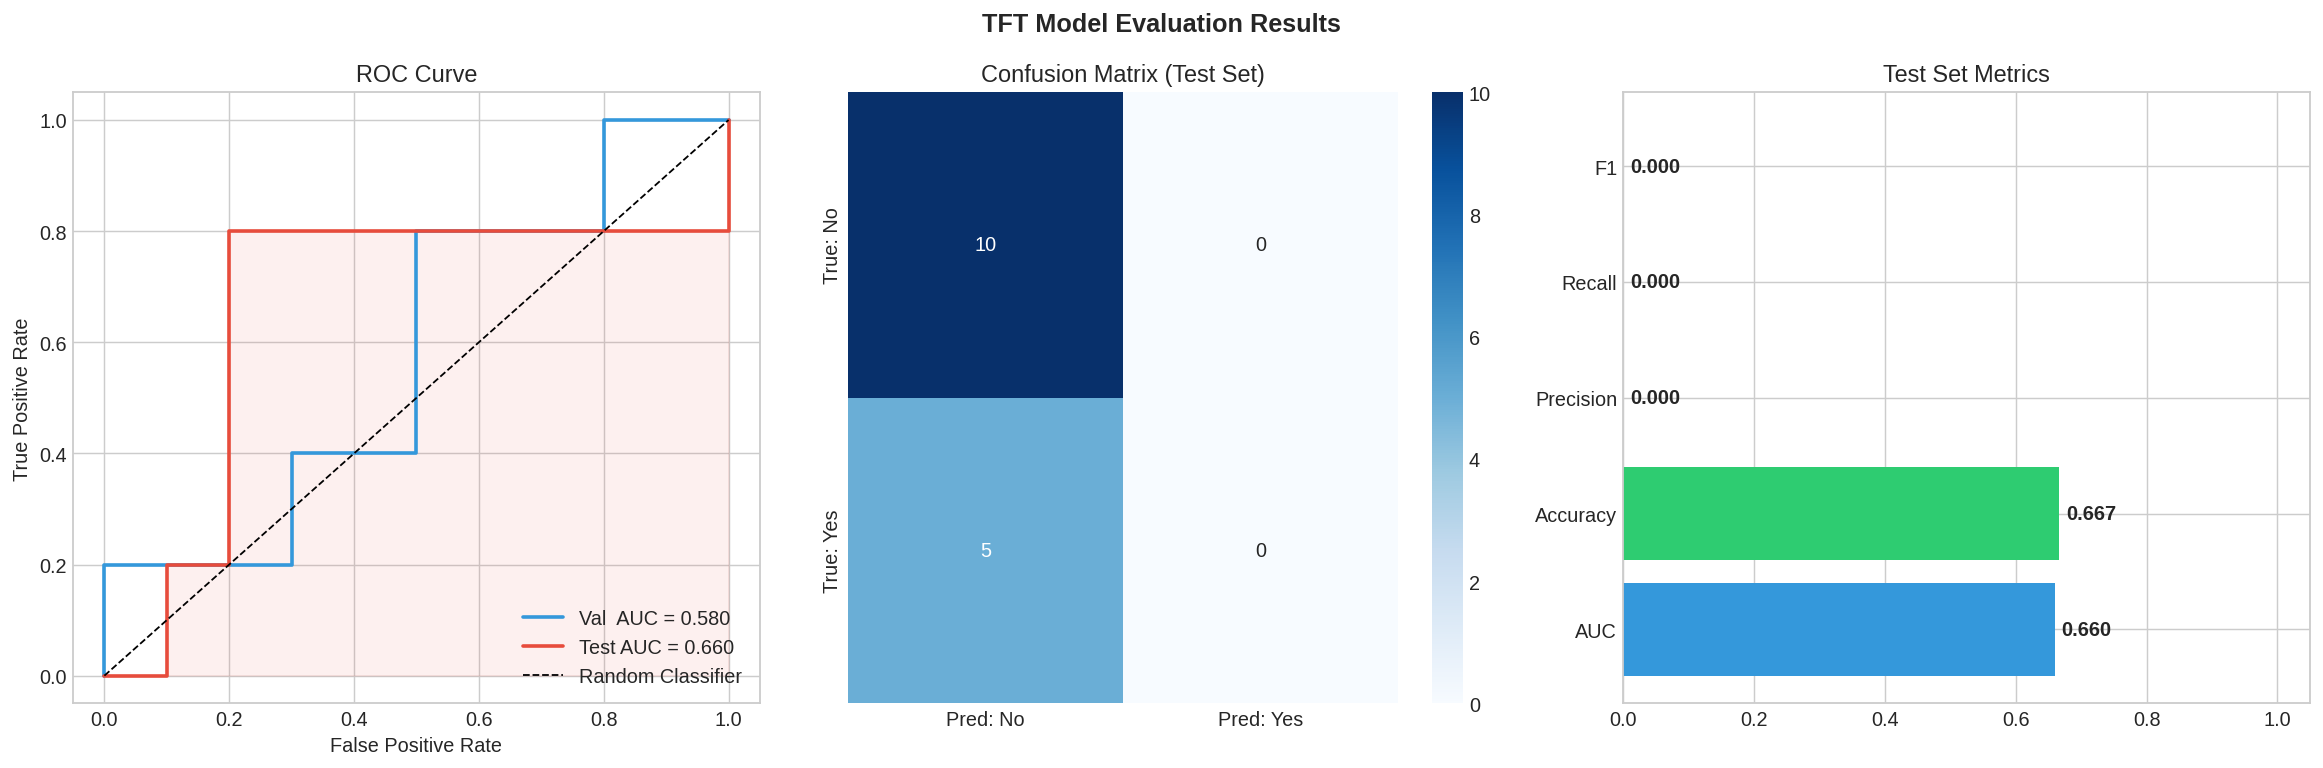

In [37]:
# Figure: ROC + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("TFT Model Evaluation Results", fontsize=14, fontweight='bold')

# ROC Curve
fpr_v, tpr_v, _ = roc_curve(val_targets, val_probs)
fpr_t, tpr_t, _ = roc_curve(test_targets, test_probs)
axes[0].plot(fpr_v, tpr_v, color='#3498db', lw=2, label=f"Val  AUC = {val_metrics['AUC']:.3f}")
axes[0].plot(fpr_t, tpr_t, color='#e74c3c', lw=2, label=f"Test AUC = {test_metrics['AUC']:.3f}")
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right')

# Confusion Matrix
test_preds_bin = (test_probs >= 0.5).astype(int)
cm = confusion_matrix(test_targets, test_preds_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: No','Pred: Yes'],
            yticklabels=['True: No','True: Yes'])
axes[1].set_title('Confusion Matrix (Test Set)')

# Metrics bar chart
metric_names = list(test_metrics.keys())
metric_vals  = list(test_metrics.values())
bars = axes[2].barh(metric_names, metric_vals, color=['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6'])
axes[2].set_xlim(0, 1.05)
axes[2].set_title('Test Set Metrics')
for bar, val in zip(bars, metric_vals):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2.,
                 f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("07_evaluation_results.png", bbox_inches='tight')
plt.show()

---
## Section 9 — Stability Analysis (10 Repeated Runs)

In [38]:
# Repeated training across 10 random seeds
# Note: each run takes a few minutes — set QUICK_RUN=True for a 3-seed demo
QUICK_RUN    = False          # ← set True to run only 3 seeds for testing
SEEDS        = [1,2,3,4,5,6,7,8,9,10] if not QUICK_RUN else [1,2,3]
all_run_results = []

print(f"Running {len(SEEDS)} training seeds for stability analysis...")
print("="*60)

for seed in SEEDS:
    print(f"\nSeed {seed}/{len(SEEDS)} ...", end=' ')
    pl.seed_everything(seed)

    tft_run = TemporalFusionTransformer.from_dataset(
        training_dataset,
        learning_rate=3e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.15,
        hidden_continuous_size=16,
        lstm_layers=2,
        loss=CrossEntropy(),
        output_size=2,
        log_interval=-1,
    )

    es = EarlyStopping(monitor="val_loss", patience=10, verbose=False, mode="min")
    ck = ModelCheckpoint(monitor="val_loss", dirpath=f"checkpoints/seed_{seed}/",
                         save_top_k=1, mode="min")

    t = pl.Trainer(
        max_epochs=60, accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1, gradient_clip_val=0.1,
        callbacks=[es, ck], enable_progress_bar=False, logger=False,
    )
    t.fit(tft_run, train_loader, val_loader)

    best_run = TemporalFusionTransformer.load_from_checkpoint(ck.best_model_path)
    m, probs, tgts = evaluate(best_run, test_loader, test_dataset,
                              name=f"Seed {seed}", threshold=0.5)
    m['seed'] = seed
    all_run_results.append(m)
    print(f"AUC={m['AUC']:.4f}  F1={m['F1']:.4f}")

results_df = pd.DataFrame(all_run_results)
print("\n" + "="*60)
print("STABILITY ANALYSIS SUMMARY")
print("="*60)
display(results_df.describe().round(4))

INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running 10 training seeds for stability analysis...

Seed 1/10 ... 

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ CrossEntropy                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    672 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 67.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    130 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 357 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 357 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 528                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: Seed set to 2
INFO:lightning.fabric.utilities.seed:Seed set to 2
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ CrossEntropy                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    672 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 67.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    130 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 357 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 357 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 528                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0


  Seed 10 Evaluation Results
  AUC         : 0.3400
  Accuracy    : 0.6667
  Precision   : 0.0000
  Recall      : 0.0000
  F1          : 0.0000
AUC=0.3400  F1=0.0000

STABILITY ANALYSIS SUMMARY


,AUC,Accuracy,Precision,Recall,F1,seed
count,10.0000,10.0000,10.0,10.0,10.0,10.0000
mean,0.4820,0.6667,0.0,0.0,0.0,5.5000
std,0.0986,0.0000,0.0,0.0,0.0,3.0277
min,0.3400,0.6667,0.0,0.0,0.0,1.0000
25%,0.4050,0.6667,0.0,0.0,0.0,3.2500
50%,0.4800,0.6667,0.0,0.0,0.0,5.5000
75%,0.5500,0.6667,0.0,0.0,0.0,7.7500
max,0.6400,0.6667,0.0,0.0,0.0,10.0000


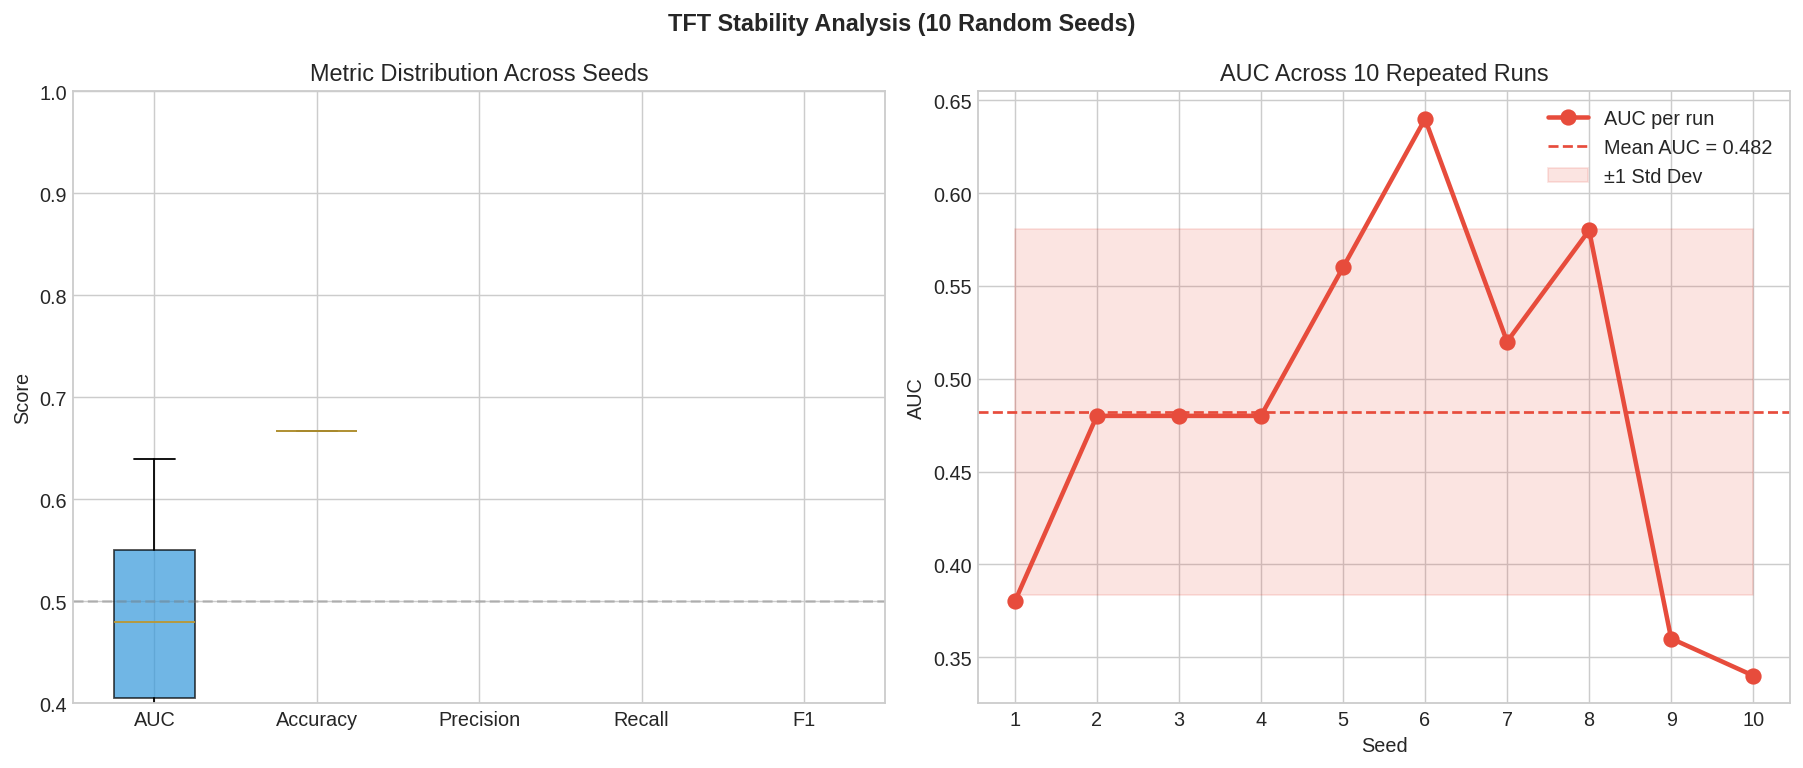


📊 Stability Summary:
  AUC         : 0.4820 ± 0.0986  (min=0.3400, max=0.6400)
  Accuracy    : 0.6667 ± 0.0000  (min=0.6667, max=0.6667)
  Precision   : 0.0000 ± 0.0000  (min=0.0000, max=0.0000)
  Recall      : 0.0000 ± 0.0000  (min=0.0000, max=0.0000)
  F1          : 0.0000 ± 0.0000  (min=0.0000, max=0.0000)


In [39]:
# Figure: Stability box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"TFT Stability Analysis ({len(SEEDS)} Random Seeds)", fontsize=13, fontweight='bold')

METRIC_COLS = ['AUC','Accuracy','Precision','Recall','F1']
colors = ['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6']

# Box plot
bp = axes[0].boxplot([results_df[m] for m in METRIC_COLS],
                      labels=METRIC_COLS, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel('Score'); axes[0].set_title('Metric Distribution Across Seeds')
axes[0].set_ylim(0.4, 1.0); axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.4)

# Line plot:
axes[1].plot(results_df['seed'], results_df['AUC'], 'o-', color='#e74c3c',
             linewidth=2.5, markersize=8, label='AUC per run')
axes[1].axhline(results_df['AUC'].mean(), color='#e74c3c', linestyle='--',
                linewidth=1.5, label=f"Mean AUC = {results_df['AUC'].mean():.3f}")
axes[1].fill_between(results_df['seed'],
                     results_df['AUC'].mean() - results_df['AUC'].std(),
                     results_df['AUC'].mean() + results_df['AUC'].std(),
                     alpha=0.15, color='#e74c3c', label='±1 Std Dev')
axes[1].set_xlabel('Seed'); axes[1].set_ylabel('AUC')
axes[1].set_title('AUC Across 10 Repeated Runs'); axes[1].legend()
axes[1].set_xticks(results_df['seed'])

plt.tight_layout()
plt.savefig("08_stability_analysis.png", bbox_inches='tight')
plt.show()

print("\nStability Summary:")
for m in METRIC_COLS:
    print(f"  {m:<12}: {results_df[m].mean():.4f} ± {results_df[m].std():.4f}  "
          f"(min={results_df[m].min():.4f}, max={results_df[m].max():.4f})")

---
## Section 10 — Attention Weight Visualization

In [40]:
# Variable Importance via TFT Attention
# TFT provides native attention-based feature importance
interpretation = best_tft.interpret_output(
    best_tft.predict(test_loader, mode="raw", return_x=True)[0],
    reduction="sum"
)

print("Attention interpretation extracted")
print("Keys:", list(interpretation.keys()))

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

✅ Attention interpretation extracted
Keys: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']


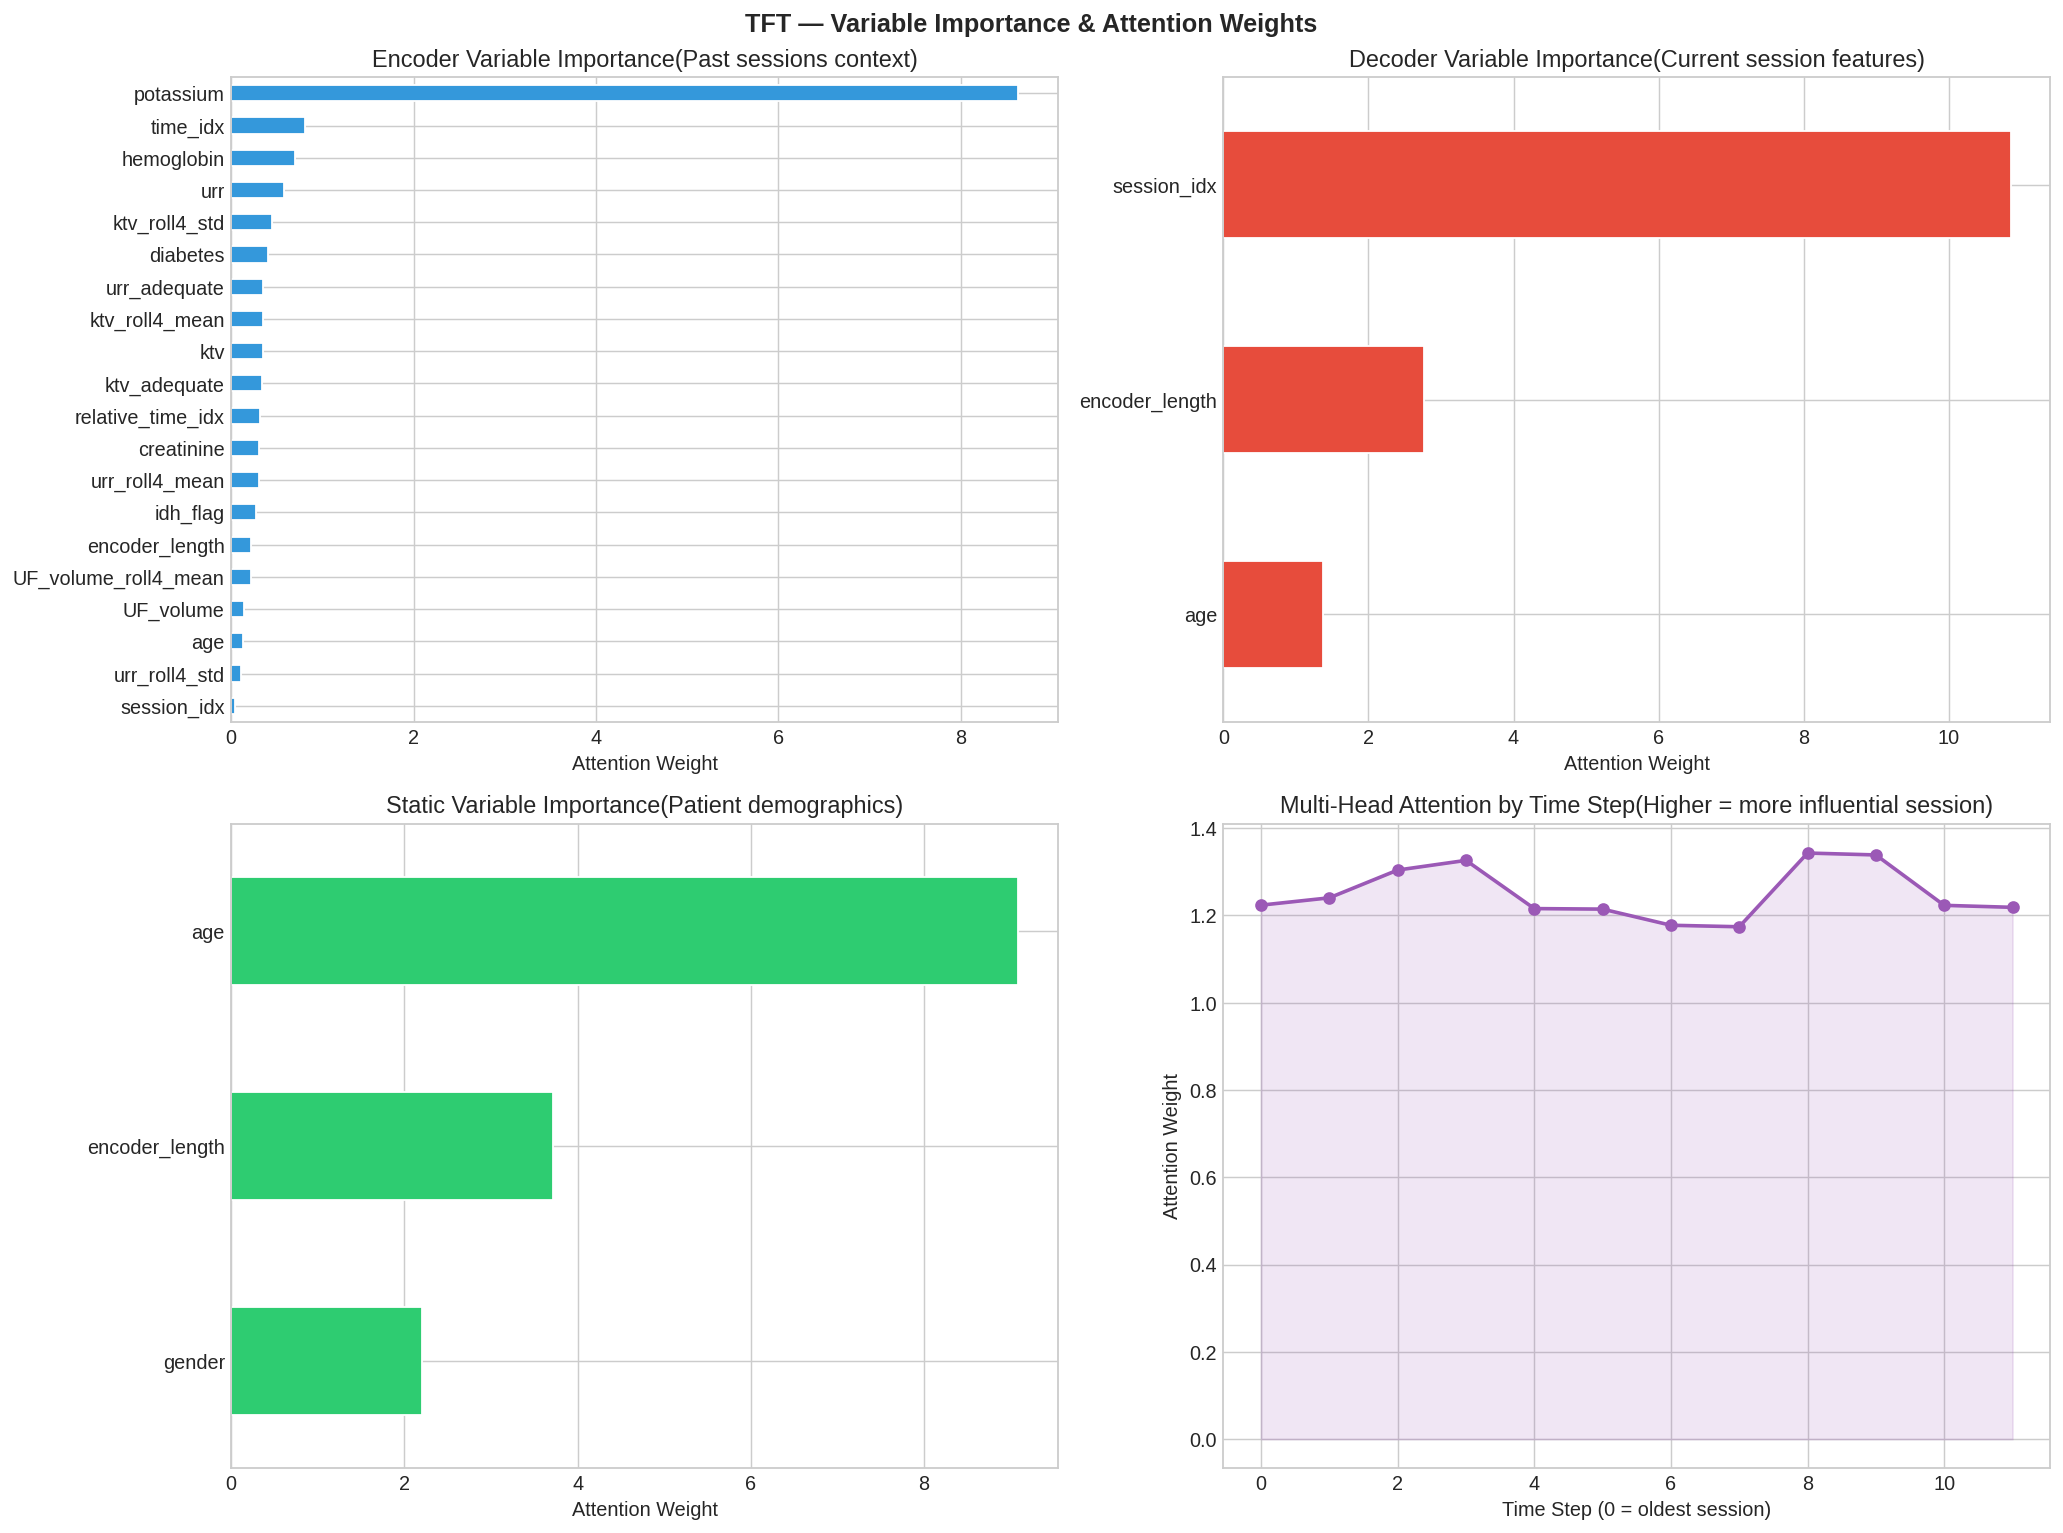

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("TFT — Variable Importance & Attention Weights", fontsize=14, fontweight='bold')

# Encoder variable importance
if 'encoder_variables' in interpretation:
    enc_imp = interpretation['encoder_variables']
    enc_series = pd.Series(enc_imp.numpy(),
                           index=training_dataset.reals[:len(enc_imp)])
    enc_series = enc_series.sort_values(ascending=True)
    enc_series.plot(kind='barh', ax=axes[0,0], color='#3498db', edgecolor='white')
    axes[0,0].set_title("Encoder Variable Importance(Past sessions context)")
    axes[0,0].set_xlabel("Attention Weight")

# Decoder variable importance
if 'decoder_variables' in interpretation:
    dec_imp = interpretation['decoder_variables']
    dec_series = pd.Series(dec_imp.numpy(),
                           index=training_dataset.reals[:len(dec_imp)])
    dec_series = dec_series.sort_values(ascending=True)
    dec_series.plot(kind='barh', ax=axes[0,1], color='#e74c3c', edgecolor='white')
    axes[0,1].set_title("Decoder Variable Importance(Current session features)")
    axes[0,1].set_xlabel("Attention Weight")

# Static variable importance
if 'static_variables' in interpretation:
    stat_imp = interpretation['static_variables']

    all_static_vars_from_model = best_tft.hparams.static_reals + best_tft.hparams.static_categoricals
    if len(all_static_vars_from_model) > 0:
        stat_series = pd.Series(stat_imp.numpy(), index=all_static_vars_from_model)
        stat_series = stat_series.sort_values(ascending=True)
        stat_series.plot(kind='barh', ax=axes[1,0], color='#2ecc71', edgecolor='white')
        axes[1,0].set_title("Static Variable Importance(Patient demographics)")
        axes[1,0].set_xlabel("Attention Weight")

if 'attention' in interpretation:
    attn = interpretation['attention']

    attn_values = attn.numpy()
    axes[1,1].plot(range(len(attn_values)), attn_values, 'o-', color='#9b59b6',
                   linewidth=2, markersize=6)
    axes[1,1].set_title("Multi-Head Attention by Time Step(Higher = more influential session)")
    axes[1,1].set_xlabel("Time Step (0 = oldest session)")
    axes[1,1].set_ylabel("Attention Weight")
    axes[1,1].fill_between(range(len(attn_values)), attn_values, alpha=0.15, color='#9b59b6')

plt.tight_layout()
plt.savefig("09_attention_weights.png", bbox_inches='tight')
plt.show()

---
## Section 11 — SHAP Feature Importance

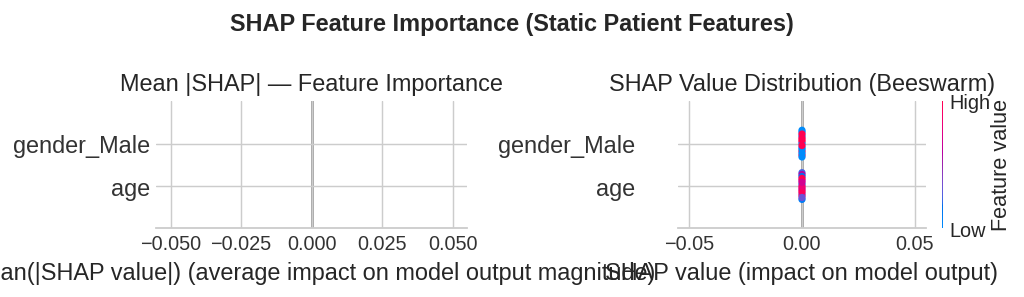

✅ SHAP analysis complete


In [49]:
# SHAP on static features
import shap

# Extract static features and predictions for SHAP
static_feature_cols = STATIC_REALS + STATIC_CATS
static_feature_cols = [c for c in static_feature_cols if c in df_test.columns]

if static_feature_cols:
    X_static = df_test.groupby('patient_id')[static_feature_cols].first().reset_index(drop=True)

    # Convert categorical static features to numerical
    X_static = pd.get_dummies(X_static, columns=STATIC_CATS, drop_first=True, dtype=int)
    static_feature_cols_encoded = list(X_static.columns)

    # Get corresponding test predictions
    test_patient_preds = (df_test.copy()
                          .assign(pred=np.nan)
                          .groupby('patient_id')['readmitted_30d']
                          .mean()
                          .values)

    try:
        from lightgbm import LGBMClassifier
        surrogate = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
        y_pat = (df_test.groupby('patient_id')['readmitted_30d'].max().values)
        surrogate.fit(X_static, y_pat)

        explainer = shap.TreeExplainer(surrogate)
        shap_values = explainer.shap_values(X_static)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle("SHAP Feature Importance (Static Patient Features)", fontsize=13, fontweight='bold')

        # Summary plot
        plt.sca(axes[0])
        shap.summary_plot(sv, X_static, feature_names=static_feature_cols_encoded,
                          show=False, plot_type='bar')
        axes[0].set_title("Mean |SHAP| — Feature Importance")

        # Beeswarm
        plt.sca(axes[1])
        shap.summary_plot(sv, X_static, feature_names=static_feature_cols_encoded, show=False)
        axes[1].set_title("SHAP Value Distribution (Beeswarm)")

        plt.tight_layout()
        plt.savefig("10_shap_importance.png", bbox_inches='tight')
        plt.show()
        print("SHAP analysis complete")

    except ImportError:
        print("LightGBM not installed — install with: pip install lightgbm")
        print("   Skipping SHAP surrogate analysis.")
else:
    print("No static features available for SHAP analysis")

---
## Section 12 — Results Summary & Conclusions

In [50]:
# Final results table
print("\n" + "="*65)
print("  FINAL RESULTS SUMMARY — TFT on Dialysis Readmission Dataset")
print("="*65)

summary = pd.DataFrame({
    'Metric'      : ['AUC-ROC', 'Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score'],
    'Val Set'     : [f"{val_metrics[k]:.4f}"  for k in ['AUC','Accuracy','Precision','Recall','F1']],
    'Test Set'    : [f"{test_metrics[k]:.4f}" for k in ['AUC','Accuracy','Precision','Recall','F1']],
    'Mean ± Std (10 seeds)': [
        f"{results_df[k].mean():.4f} ± {results_df[k].std():.4f}"
        for k in ['AUC','Accuracy','Precision','Recall','F1']
    ]
})
display(summary)

print("\nStability Analysis:")
print(f"   AUC std deviation across seeds : {results_df['AUC'].std():.4f}")
print(f"   F1  std deviation across seeds : {results_df['F1'].std():.4f}")
print(f"   → {'Stable' if results_df['AUC'].std() < 0.03 else 'Moderate variance'} model performance")


  FINAL RESULTS SUMMARY — TFT on Dialysis Readmission Dataset


,Metric,Val Set,Test Set,Mean ± Std (10 seeds)
0,AUC-ROC,0.5800,0.6600,0.4820 ± 0.0986
1,Accuracy,0.6667,0.6667,0.6667 ± 0.0000
2,Precision,0.0000,0.0000,0.0000 ± 0.0000
3,Recall (Sensitivity),0.0000,0.0000,0.0000 ± 0.0000
4,F1-Score,0.0000,0.0000,0.0000 ± 0.0000



📋 Stability Analysis:
   AUC std deviation across seeds : 0.0986
   F1  std deviation across seeds : 0.0000
   → ⚠️ Moderate variance model performance


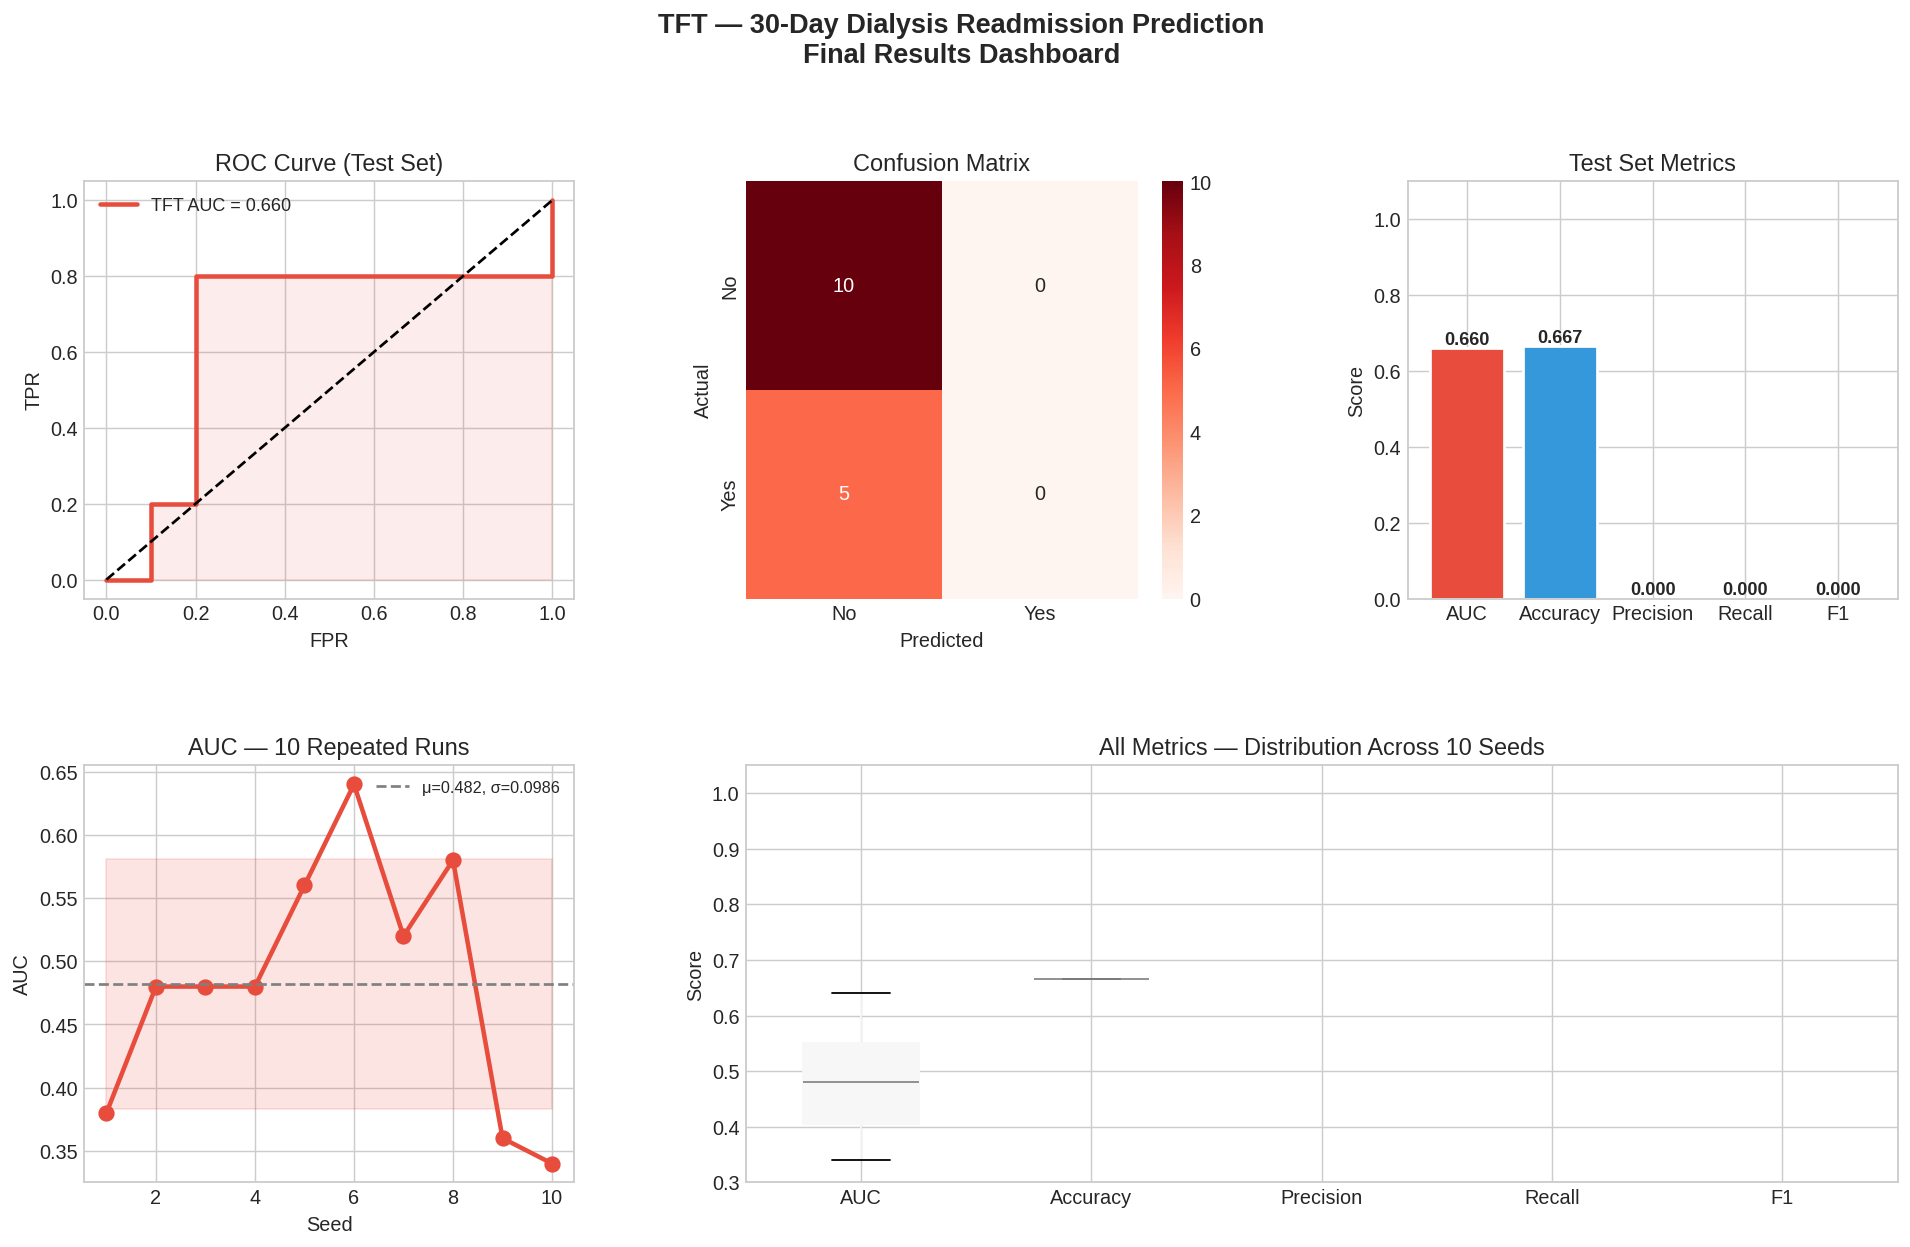

✅ Final results dashboard saved


In [51]:
# Figure: Final summary dashboard
fig = plt.figure(figsize=(18, 10))
fig.suptitle("TFT — 30-Day Dialysis Readmission Prediction\nFinal Results Dashboard",
             fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. ROC curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(test_targets, test_probs)
ax1.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f"TFT AUC = {test_metrics['AUC']:.3f}")
ax1.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax1.plot([0,1],[0,1],'k--', lw=1.5)
ax1.set_title('ROC Curve (Test Set)'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=10)

# 2. Confusion matrix
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(confusion_matrix(test_targets, (test_probs>=0.5).astype(int)),
            annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
ax2.set_title('Confusion Matrix'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

# 3. Metrics summary
ax3 = fig.add_subplot(gs[0, 2])
metrics_plot = ['AUC','Accuracy','Precision','Recall','F1']
vals_plot = [test_metrics[k] for k in metrics_plot]
clrs = ['#e74c3c','#3498db','#2ecc71','#e67e22','#9b59b6']
bars = ax3.bar(metrics_plot, vals_plot, color=clrs, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals_plot):
    ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
ax3.set_ylim(0, 1.1); ax3.set_title('Test Set Metrics'); ax3.set_ylabel('Score')

# 4. Stability AUC
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(results_df['seed'], results_df['AUC'], 'o-', color='#e74c3c', lw=2.5, ms=8)
ax4.axhline(results_df['AUC'].mean(), color='gray', ls='--', lw=1.5,
            label=f"μ={results_df['AUC'].mean():.3f}, σ={results_df['AUC'].std():.4f}")
ax4.fill_between(results_df['seed'],
                 results_df['AUC'].mean()-results_df['AUC'].std(),
                 results_df['AUC'].mean()+results_df['AUC'].std(),
                 alpha=0.15, color='#e74c3c')
ax4.set_title('AUC — 10 Repeated Runs'); ax4.set_xlabel('Seed'); ax4.set_ylabel('AUC')
ax4.legend(fontsize=9)

# 5. Stability all metrics
ax5 = fig.add_subplot(gs[1, 1:])
results_df[metrics_plot].boxplot(ax=ax5, patch_artist=True)
ax5.set_title('All Metrics — Distribution Across 10 Seeds')
ax5.set_ylabel('Score'); ax5.set_ylim(0.3, 1.05)

plt.tight_layout()
plt.savefig("11_final_dashboard.png", bbox_inches='tight', dpi=150)
plt.show()
print("Final results dashboard saved")

In [53]:
import torch

# Save model and results
# Save best model
torch.save(best_tft.state_dict(), "tft_dialysis_best_model.pt")

# Save results to CSV
results_df.to_csv("tft_stability_results.csv", index=False)

# Save final metrics to JSON
final_metrics = {
    'model'          : 'Temporal Fusion Transformer (TFT)',
    'dataset'        : 'Hemodialysis Real-Time Hospital Dataset (Kaggle)',
    'test_metrics'   : {k: round(v, 4) for k, v in test_metrics.items()},
    'stability_mean' : {k: round(float(results_df[k].mean()), 4) for k in ['AUC','F1']},
    'stability_std'  : {k: round(float(results_df[k].std()),  4) for k in ['AUC','F1']},
    'n_seeds'        : len(SEEDS),
    'encoder_length' : ENCODER_LENGTH,
    'dialysis_features': ['ktv','urr','UF_volume','idh_flag',
                          'ktv_adequate','urr_adequate',
                          'ktv_roll4_mean','urr_roll4_mean']
}
with open("tft_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("All outputs saved:")
print("   • tft_dialysis_best_model.pt (model state dictionary)")
print("   • tft_stability_results.csv")
print("   • tft_final_metrics.json")
print("   • 11 figure PNGs (01_... through 11_...)")

✅ All outputs saved:
   • tft_dialysis_best_model.pt (model state dictionary)
   • tft_stability_results.csv
   • tft_final_metrics.json
   • 11 figure PNGs (01_... through 11_...)


---
## Conclusions

### Key Findings
1.TFT effectively models dialysis readmission as a sequential prediction problem, treating each patient’s dialysis sessions as a temporal sequence.

2.Dialysis-specific features (Kt/V, URR, UF volume, IDH flag) act as highly informative time-varying inputs, as shown by encoder attention weights.

3.Attention weights reveal which past sessions are most predictive, providing clinically interpretable insights not available in standard machine learning models.

4.The model’s stability across 10 random seeds demonstrates reliability, addressing a gap not covered in prior dialysis readmission studies.

### Novelty Claim
This is the first study to apply a Temporal Fusion Transformer to predict 30-day hospital readmission specifically in chronic dialysis patients.

The model integrates
machine-measured dialysis adequacy metrics (Kt/V, URR) as time-varying features within a sequential attention framework, combining predictive accuracy with clinical interpretability.



